<div align="center">

# 🎬 IMDb Rating Prediction

### Pre-Release Movie Rating Forecasting

**Final Project · Machine Learning Course**

</div>

---

|                  |                                                                                  |
|------------------|----------------------------------------------------------------------------------|
| **Submitters**   | _[שקד אמסלם]_ · _[זוהי סחייק]_                                                          |
| **Repository**   | [github.com/Shakedams/imdb-rating-prediction](https://github.com/Shakedams/imdb-rating-prediction) |
| **Submitted Model** | Elastic Net (with logit target transformation)                                |
| **Second Model**    | Random Forest (used in the 5–13 analysis sections)                          |

---


# 🎬 IMDb Rating Prediction — Pre-Release

## Machine Learning Final Project — Part 2

Predict `averageRating` (1–10) for movies using only information available **before theatrical release**.

---

## 📋 Table of Contents

### Part A — Data Preparation
1. Imports & Configuration
2. Load Dataset
3. Cleaning & Parsers
4. IMDB Enrichment
   - 4.1 Download IMDB Tables
   - 4.2 Build History Dictionaries (Leakage-Free)
5. TMDB Enrichment (Budget, MPAA, Release Month)
6. Exploratory Data Analysis

### Part B — Feature Engineering & Modeling
7. Feature Engineering
   - 7.1 Feature Functions
   - 7.2 `prepare_data()` Function
   - 7.3 Tests (single-row, batch, no leakage)
8. Modeling
   - 8.1 CV Framework
   - 8.2 Elastic Net (with Optuna tuning)
   - 8.3 Random Forest (with Optuna tuning)
   - 8.4 Model Comparison

### Part C — Analysis
9. Feature Importance
10. Prediction Diagnostics
11. Error Analysis
12. Plot Text Ablation Test
13. Fairness Analysis
14. Leakage Prevention — Executable Verification

### Part D — Submission
15. Save Model & Enrichment
16. Compatibility Test
17. Summary

---

## ⚙️ Runtime Shortcuts

The notebook supports several caches that significantly reduce runtime:

| Cache file | Saves | Behavior if missing |
|-----------|-------|---------------------|
| `.imdb_cache/` (auto-created) | ~10 min IMDB download | Will download |
| `enriched_dataset.csv` (optional) | 4–6 hours TMDB API | Falls back to TMDB API |
| Hardcoded best params | ~3 hours Optuna tuning | Set `RUN_OPTUNA=True` to re-run |

**Minimum input required: `dataset.csv` in working directory.** With `enriched_dataset.csv` and the pre-trained `model.pkl` + `enrichment_globals.pkl`, the prof's test code runs in seconds.

---

## 🔒 Data Leakage Prevention

1. Forbidden variables (`averageRating`, `numVotes`, `BoxOffice`) **never** appear as features.
2. Every historical feature filters to `year < target_year`.
3. All preprocessing (`Imputer`, `Scaler`, `TargetEncoder`, `TFIDF+SVD`) lives **inside** the sklearn Pipeline and is fit on the training fold only.
4. Movies released after 2024 are dropped — their ratings aren't yet stable.
5. `n_markets` is **not used as a feature**. It would count regions in IMDb's akas table, but that table accumulates post-release international distribution — a movie with high `n_markets` was distributed widely *because* it became a hit. The akas table is still used to fill `Language` / `Country` (pre-release attributes).
6. Plot text is aggressively cleaned: sentences containing awards, reviews, "critical/commercial success", etc. are stripped. The remaining ablation is quantified in 12.
7. Executable verification in Section 14.

---

## 🎯 Models

- **Competition submission (`model.pkl`):** Elastic Net — required by the assignment as the tuned EN.
- **Second model (assignment 3.2):** Random Forest — used in the analysis sections (Error, Fairness, Feature Importance).


## 1. Imports & Configuration

In [1]:
# ── Suppress noisy warnings (keep critical ones) ─────────────────────────
import warnings
warnings.filterwarnings('ignore')
import pandas as _pd_warn; _pd_warn.options.mode.chained_assignment = None

# ── Standard library ─────────────────────────────────────────────────────
import ast, re, json, gzip, io, time, os
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Scientific stack ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
from tqdm.auto import tqdm
tqdm.pandas()

# ── scikit-learn ─────────────────────────────────────────────────────────
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import (
    cross_validate, KFold, cross_val_predict, cross_val_score
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── sklearn version check ───────────────────────────────────────────────
# model.pkl was saved with scikit-learn 1.6.1. Newer versions (1.7+) removed
# internal classes that the pickle relies on (e.g. _RemainderColsList).
# If the prof runs with a different version, give a clear, actionable error.
_REQUIRED_SKLEARN = '1.6.1'
if sklearn.__version__ != _REQUIRED_SKLEARN:
    print(f"⚠️  WARNING: scikit-learn version mismatch")
    print(f"    Installed: {sklearn.__version__}")
    print(f"    Required:  {_REQUIRED_SKLEARN}")
    print(f"    Fix:       pip install scikit-learn=={_REQUIRED_SKLEARN}")
    print(f"    (model.pkl and enrichment_globals.pkl were saved with {_REQUIRED_SKLEARN})")
else:
    print(f"✅ scikit-learn {sklearn.__version__}")

# ── Reproducibility ──────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

# ── Runtime flags ────────────────────────────────────────────────────────
RUN_OPTUNA   = False   # True → re-tune (~3 hours); False → use hardcoded best params
SKIP_TMDB    = False   # True → skip TMDB API entirely (some features will be NaN)

# Max movies to fetch from TMDB per run. 25K covers all movies with ~300+ votes.
TMDB_FETCH_LIMIT = 100_000

# ── External APIs ────────────────────────────────────────────────────────
# TMDB API key — read from env if present, else fall back to a public key.
TMDB_API_KEY = os.getenv('TMDB_API_KEY', 'fb7bb23f03b6994dafc674c074d01761')
TMDB_BASE    = 'https://api.themoviedb.org/3'
IMDB_BASE    = 'https://datasets.imdbws.com/'

# ── Paths ────────────────────────────────────────────────────────────────
DATASET_PATH  = 'dataset.csv'
ENRICHED_CSV  = 'enriched_dataset.csv'   # optional fast-path cache

if not os.path.isfile(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_PATH}'. "
        f"Place dataset.csv in the working directory."
    )
print(f"Dataset:  {DATASET_PATH}")
print(f"Optuna:   {'ENABLED (slow)' if RUN_OPTUNA else 'disabled (using cached params)'}")
print(f"TMDB:     {'enabled' if not SKIP_TMDB else 'SKIPPED'}")

# ── Currency exchange rates for budget normalization ────────────────────
FX = {
    'INR':1/75,'GBP':1.27,'EUR':1.10,'AUD':0.65,'CAD':0.75,
    'JPY':1/110,'KRW':1/1300,'DKK':1/6.9,'SEK':1/10.3,'MYR':1/4.4,
    'DEM':1/1.8,'CZK':1/22.5,'PHP':1/56,'UAH':1/28,'BDT':1/110,
    'CNY':1/7,'HKD':1/7.8,'BRL':1/5.2,'USD':1.0,
}

# ── Top 20 genres (used for one-hot encoding) ───────────────────────────
TOP_GENRES = [
    'Drama','Comedy','Documentary','Romance','Action','Crime','Thriller',
    'Horror','Adventure','Mystery','Family','Biography','Fantasy','Music',
    'History','Sci-Fi','War','Animation','Sport','Musical'
]

print("\n✅ Imports & configuration complete")


⚠️  WARNING: scikit-learn version mismatch
    Installed: 1.8.0
    Required:  1.6.1
    Fix:       pip install scikit-learn==1.6.1
    (model.pkl and enrichment_globals.pkl were saved with 1.6.1)
Dataset:  dataset.csv
Optuna:   disabled (using cached params)
TMDB:     enabled

✅ Imports & configuration complete


## 2. Load Dataset

In [2]:
# Load the raw dataset from Part 1
df_raw = pd.read_csv(DATASET_PATH, low_memory=False)
print(f"Raw shape: {df_raw.shape}")
print(f"\nColumn coverage:")
for col in df_raw.columns:
    pct = df_raw[col].notna().mean() * 100
    print(f"  {col:<20}: {pct:5.1f}%")


Raw shape: (133884, 13)

Column coverage:
  tconst              : 100.0%
  primaryTitle        : 100.0%
  startYear           : 100.0%
  genres              :  98.1%
  lead_actors_ids     :  92.5%
  runtimeMinutes      : 100.0%
  averageRating       :  86.3%
  Language            :  41.6%
  Country             :  40.1%
  numVotes            :  93.2%
  budget              :  12.4%
  BoxOffice           :  13.4%
  plot                :  44.6%


## 3. Cleaning & Parsers

In [3]:
# ─────────────────────────────────────────────────────────────────────────
# Parser functions — used by both the cleaning step and prepare_data()
# ─────────────────────────────────────────────────────────────────────────

def parse_actor_list(raw):
    """Parse lead_actors_ids string into list of nconst IDs."""
    if isinstance(raw, list):
        return raw
    if pd.isna(raw) or not raw:
        return []
    try:
        parsed = ast.literal_eval(str(raw))
        if isinstance(parsed, list):
            return [x.strip() for x in parsed
                    if isinstance(x, str) and x.strip().startswith('nm')]
        return []
    except Exception:
        return [x.strip() for x in re.findall(r'nm\d+', str(raw))]


def parse_genres(raw):
    """Normalize genre strings to comma-separated form.

    Handles three input formats:
      - "Drama, Comedy"           (already clean)
      - "['Drama', 'Comedy']"     (string repr of Python list)
      - "Drama|Comedy"            (pipe-separated)

    Returns canonical "Drama,Comedy" or np.nan.
    """
    if pd.isna(raw) or not raw:
        return np.nan
    s = str(raw).strip()
    if s.lower() in ('nan', 'none', '\\n', ''):
        return np.nan
    s = s.strip("[]").replace("'", "").replace('"', "").replace('|', ',')
    parts = [p.strip() for p in s.split(',') if p.strip()]
    seen = set()
    unique = [p for p in parts if not (p in seen or seen.add(p))]
    return ','.join(unique) if unique else np.nan


def clean_plot(raw):
    """Clean plot text — remove HTML, footnote markers, and post-release content.

    Removes:
      1. HTML tags
      2. Wikipedia footnote markers like [1], [12]
      3. Sentences with post-release content (awards, reviews, box office)
      4. Wikipedia-style opener "X is a YEAR film by..."
      5. Plots too short or marked as placeholder
    """
    if pd.isna(raw) or not raw:
        return np.nan
    s = str(raw)

    # Remove HTML tags
    s = re.sub(r'<[^>]+>', '', s)

    # Remove footnote markers
    s = re.sub(r'\[\d+\]', '', s)

    # Strip sentences containing post-release signals (potential leakage)
    post_release_patterns = [
        r'\b(won|received|got|earned|nominated for|honored with)\s+(?:the\s+)?(?:\w+\s+){0,5}?(Award|Oscar|Globe|Razzie|Bafta|Goya|Prize|Best [A-Z]\w+)\b',
        r'\b(critical acclaim|critically acclaimed|received praise|received mixed reviews|received negative)\b',
        r'\b(cult classic|cult following|cult favorite)\b',
        r'\b(highest grossing|top.grossing|best.selling|biggest hit)\b',
        r'\bbox office (hit|success|failure|bomb|smash|disappointment)\b',
        r'\b(critical|commercial|financial)\s+(?:(?:and|or)\s+\w+\s+)*(success|failure|hit|flop|bomb|disappointment|smash|disaster|acclaim)\b',
        r'\b(praised|criticized|panned)\s+by\s+(critics|reviewers|audiences)\b',
        r'\b(critics|reviewers|audiences)\s+(praised|criticized|panned|gave)\b',
        r'\b(spawned|launched|inspired)\s+(?:a\s+)?(sequel|franchise|series|remake)\b',
        r'\bAcademy Award\b',
        r'\bGolden Globe\b',
        r'\bSaturn Award\b',
    ]
    sentences = re.split(r'(?<=[.!?])\s+', s)
    keep = [s_ for s_ in sentences
            if not any(re.search(p, s_, re.IGNORECASE) for p in post_release_patterns)]
    s = ' '.join(keep)

    # Strip Wikipedia-style opener
    s = re.sub(
        r'^[A-Z][^.]*?is a \d{4}[^.]*?(film|movie|drama|comedy|thriller|documentary)[^.]*?\.\s*',
        '', s, count=1, flags=re.IGNORECASE)

    # Collapse whitespace
    s = re.sub(r'\s+', ' ', s).strip()

    # Reject too-short or placeholder
    if len(s) < 30 or s.lower() in ('nan', 'none', 'not found', 'no plot', 'plot unknown'):
        return np.nan
    return s


def clean_country(raw):
    """Normalize Country: strip footnote markers and wrapping quotes/brackets."""
    if pd.isna(raw) or not raw:
        return np.nan
    s = str(raw).strip()
    if s.lower() in ('nan', 'none', '\\n', '', 'not found', 'xww', 'unknown'):
        return np.nan
    s = re.sub(r'\s*\[\s*[a-zA-Z0-9]{1,4}\s*\]', '', s)
    while s and s[0] in "[]'\"":  s = s[1:]
    while s and s[-1] in "[]'\"": s = s[:-1]
    s = re.sub(r'\s+', ' ', s).strip()
    if s.lower() in ('not found', 'xww', 'unknown', 'n/a', ''):
        return np.nan
    return s if s else np.nan


def clean_language(raw):
    """Normalize Language: strip footnote markers and Wikipedia-style trailing garbage."""
    if pd.isna(raw) or not raw:
        return np.nan
    s = str(raw).strip()
    if s.lower() in ('nan', 'none', '\\n', '', 'not found', 'unknown'):
        return np.nan
    s = re.sub(r'\s*\[\s*[a-zA-Z0-9]{1,4}\s*\]', '', s)
    while s and s[0] in "[]'\"":  s = s[1:]
    while s and s[-1] in "[]'\"": s = s[:-1]
    for garbage in ['Official Website', 'official website', 'See more']:
        if garbage in s:
            s = s.split(garbage)[0].strip()
    s = re.sub(r'\s+', ' ', s).strip()
    if s.lower() in ('not found', 'unknown', 'n/a', ''):
        return np.nan
    return s if s else np.nan


def clean_certification(raw):
    """Normalize MPAA certification to standard categories."""
    if pd.isna(raw) or not raw:
        return np.nan
    s = str(raw).strip().upper()
    if s in ('NAN', 'NONE', 'NOT RATED', 'NR', 'UNRATED', 'N/A', ''):
        return 'NR'
    if s in ('PG13', 'PG-13'):
        return 'PG-13'
    if s in ('NC17', 'NC-17'):
        return 'NC-17'
    if s in ('G', 'PG', 'PG-13', 'R', 'NC-17', 'NR'):
        return s
    return 'NR'


def normalize_title_for_match(title) -> str:
    """Strip leading articles & lowercase for stem matching."""
    if not isinstance(title, str): return ""
    title = title.strip()
    title = re.sub(r'^(The|A|An)\s+', '', title, flags=re.IGNORECASE)
    return title.lower()


def extract_franchise_stem(title):
    """Extract a franchise stem from a movie title if it looks like a sequel/franchise entry.
    Returns lowercase stem, or None if no franchise signal detected.

    Strategies (in order):
      1. Colon split:           "Star Wars: A New Hope" → "star wars"
      2. Trailing number/Roman: "Toy Story 2"           → "toy story"
      3. "X and the Y" pattern: "Harry Potter and the…" → "harry potter"
    """
    if not isinstance(title, str): return None
    t = normalize_title_for_match(title)
    if not t: return None

    # Strategy 1: colon
    if ':' in t:
        stem = t.split(':')[0].strip()
        if len(stem) >= 4:
            return stem

    # Strategy 2: trailing sequel marker
    cleaned = re.sub(r'\s+(part\s+\w+|\d{1,3}|[ivx]{1,5})\s*$', '', t,
                     flags=re.IGNORECASE).strip()
    if cleaned != t and len(cleaned) >= 4:
        return cleaned

    # Strategy 3: "X and the Y" (Harry Potter, Lord of the Rings sub-series)
    m = re.match(r'^(.+?)\s+and\s+the\s+', t, re.IGNORECASE)
    if m and len(m.group(1)) >= 5:
        return m.group(1).strip()

    return None


def parse_budget_to_usd_millions(raw) -> float:
    """Convert a budget string in any currency/format to USD millions."""
    try:
        if pd.isna(raw):
            return np.nan
        s = str(raw).strip()
        s_low = s.lower()

        # Direct US$ / USD patterns
        for pat in [r'US\$\s*([\d,\.]+)\s*(million|billion|thousand)?',
                    r'USD\s*([\d,\.]+)\s*(million|billion|thousand)?']:
            m = re.search(pat, s, re.I)
            if m:
                num = float(m.group(1).replace(',', ''))
                unit = (m.group(2) or '').lower()
                if unit == 'billion':
                    num *= 1000
                elif unit == 'thousand':
                    num /= 1000
                elif num >= 1000:
                    num /= 1e6
                if 0.001 <= num <= 5000:
                    return round(num, 4)

        # Detect currency from symbols
        currency = 'USD'
        if re.search(r'₹|Rs\.?\s', s):    currency = 'INR'
        elif re.search(r'£', s):           currency = 'GBP'
        elif re.search(r'€', s):           currency = 'EUR'
        elif re.search(r'¥', s):           currency = 'JPY'
        elif re.search(r'\$', s):          currency = 'USD'

        fx = FX.get(currency, 1.0)
        has_crore   = bool(re.search(r'\bcr(ore|\.?\s|$)', s_low))
        has_million = bool(re.search(r'\b(million|mio|mln)\b', s_low))

        nums = re.findall(r'[\d,]+\.?\d*', s)
        if not nums:
            return np.nan
        val = float(nums[0].replace(',', ''))

        if has_crore:    val *= 10           # 1 crore = 10 million INR
        elif has_million: pass
        elif val > 100000: val /= 1e6
        elif val > 1000:   val /= 1e3

        val *= fx
        return round(val, 4) if 0.001 <= val <= 5000 else np.nan
    except Exception:
        return np.nan


print("✅ Parser functions defined")


✅ Parser functions defined


In [4]:
# Apply parsers to the raw dataset
df = df_raw.copy()

# Numeric coercions
df['startYear']      = pd.to_numeric(df['startYear'], errors='coerce')
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
df['averageRating']  = pd.to_numeric(df['averageRating'], errors='coerce')

# Structured columns
df['lead_actors_ids'] = df['lead_actors_ids'].apply(parse_actor_list)
df['genres']          = df['genres'].apply(parse_genres)
df['Country']         = df['Country'].apply(clean_country)
df['Language']        = df['Language'].apply(clean_language)

if 'certification' in df.columns:
    df['certification'] = df['certification'].apply(clean_certification)

df['plot']       = df.get('plot', pd.Series(index=df.index)).apply(clean_plot)
df['budget_usd'] = df['budget'].apply(parse_budget_to_usd_millions)

# Filter to plausible year range
# Filter to plausible year range — drop pre-1900 (parsing errors) and post-2024
# (incomplete ratings: movies released too recently haven't accumulated stable votes,
# and 2025+ entries are often announced-but-unreleased projects).
df = df[(df['startYear'] > 1900) & (df['startYear'] <= 2024)].copy()
print(f"After cleaning: {len(df):,} rows | Rating coverage: {df['averageRating'].notna().mean():.1%}")


After cleaning: 133,408 rows | Rating coverage: 86.5%


## 4. IMDB Enrichment

### 4.1 Download IMDB Tables

In [5]:
import gc

IMDB_CACHE_DIR = '.imdb_cache'
os.makedirs(IMDB_CACHE_DIR, exist_ok=True)


def download_imdb_gz(filename, retries=3):
    """Stream-download an IMDB .tsv.gz to local disk. Reuses cached file if present."""
    local_path = os.path.join(IMDB_CACHE_DIR, filename)
    if os.path.exists(local_path) and os.path.getsize(local_path) > 1000:
        print(f"  ✓ {filename} (cached, {os.path.getsize(local_path)/1e6:.0f}MB)")
        return local_path
    for attempt in range(retries):
        try:
            print(f"  ⬇ {filename} (try {attempt+1})...", end=" ", flush=True)
            with requests.get(IMDB_BASE + filename, stream=True, timeout=180) as r:
                r.raise_for_status()
                with open(local_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192*16):
                        f.write(chunk)
            print(f"{os.path.getsize(local_path)/1e6:.0f}MB ✅")
            return local_path
        except Exception as e:
            print(f"❌ {e}")
            if attempt < retries - 1:
                time.sleep(10 * (attempt + 1))
                if os.path.exists(local_path):
                    os.remove(local_path)
            else:
                raise


def read_imdb_filtered(local_path, usecols, dtype=None,
                       filter_col=None, filter_set=None, chunksize=500_000):
    """Read .tsv.gz directly (no decompress to RAM). Optionally filter rows."""
    if filter_col is None or filter_set is None:
        return pd.read_csv(local_path, sep='\t', usecols=usecols, dtype=dtype,
                           na_values=['\\N'], low_memory=False, compression='gzip')
    chunks = []
    for chunk in pd.read_csv(local_path, sep='\t', usecols=usecols, dtype=dtype,
                             na_values=['\\N'], chunksize=chunksize,
                             compression='gzip', low_memory=False):
        chunks.append(chunk[chunk[filter_col].isin(filter_set)])
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


print("═" * 60)
print("Downloading IMDB tables (cached locally in .imdb_cache/)")
print("═" * 60)

# 1. ratings (small)
p = download_imdb_gz('title.ratings.tsv.gz')
ratings_imdb = read_imdb_filtered(p,
    usecols=['tconst', 'averageRating'], dtype={'tconst': str})
print(f"  → ratings: {len(ratings_imdb):,} rows")

# 2. basics (filter to movies only)
p = download_imdb_gz('title.basics.tsv.gz')
basics_imdb = read_imdb_filtered(p,
    usecols=['tconst', 'titleType', 'startYear', 'genres', 'runtimeMinutes'],
    dtype={'tconst': str})
basics_imdb = basics_imdb[basics_imdb['titleType'] == 'movie'].copy()
basics_imdb['startYear'] = pd.to_numeric(basics_imdb['startYear'], errors='coerce')
print(f"  → basics (movies): {len(basics_imdb):,} rows")

# Build relevant tconst set for filtering large tables
valid_tconsts    = set(basics_imdb['tconst'])
relevant_tconsts = valid_tconsts & set(ratings_imdb['tconst'])
print(f"  → Relevant tconsts: {len(relevant_tconsts):,}")

# 3. principals (~700MB - filter aggressively)
p = download_imdb_gz('title.principals.tsv.gz')
principals = read_imdb_filtered(p,
    usecols=['tconst', 'nconst', 'category', 'ordering'],
    dtype={'tconst': str, 'nconst': str},
    filter_col='tconst', filter_set=relevant_tconsts)
actors_df    = principals[principals['category'].isin(['actor', 'actress'])].copy()
directors_df = principals[principals['category'] == 'director'].copy()
producers_df = principals[principals['category'] == 'producer'].copy()
del principals
gc.collect()
print(f"  → Actors:{len(actors_df):,}  Dir:{len(directors_df):,}  Prod:{len(producers_df):,}")

# 4. crew (writers)
p = download_imdb_gz('title.crew.tsv.gz')
crew_imdb = read_imdb_filtered(p,
    usecols=['tconst', 'directors', 'writers'], dtype={'tconst': str})
print(f"  → crew: {len(crew_imdb):,} rows")

# 5. akas (filter to our dataset)
p = download_imdb_gz('title.akas.tsv.gz')
akas_imdb = read_imdb_filtered(p,
    usecols=['titleId', 'region', 'language', 'isOriginalTitle'],
    dtype={'titleId': str, 'region': str, 'language': str},
    filter_col='titleId', filter_set=set(df['tconst']))
print(f"  → akas (our movies): {len(akas_imdb):,} rows")

# 6. name.basics (filter to relevant nconsts)
relevant_nconsts = set(actors_df['nconst']) | set(directors_df['nconst']) | set(producers_df['nconst'])
p = download_imdb_gz('name.basics.tsv.gz')
name_basics = read_imdb_filtered(p,
    usecols=['nconst', 'primaryName', 'birthYear'], dtype={'nconst': str},
    filter_col='nconst', filter_set=relevant_nconsts)
print(f"  → names: {len(name_basics):,} rows")

print(f"\nDataset coverage in IMDB basics: {df['tconst'].isin(valid_tconsts).sum():,}/{len(df):,}")
print("✅ IMDB download complete")


════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════
  ✓ title.ratings.tsv.gz (cached, 8MB)
  → ratings: 1,677,177 rows
  ✓ title.basics.tsv.gz (cached, 222MB)
  → basics (movies): 748,328 rows
  → Relevant tconsts: 345,237
  ✓ title.principals.tsv.gz (cached, 768MB)
  → Actors:2,686,730  Dir:372,866  Prod:455,419
  ✓ title.crew.tsv.gz (cached, 82MB)
  → crew: 12,542,552 rows
  ✓ title.akas.tsv.gz (cached, 498MB)
  → akas (our movies): 1,600,208 rows
  ✓ name.basics.tsv.gz (cached, 304MB)
  → names: 1,125,170 rows

Dataset coverage in IMDB basics: 133,391/133,408
✅ IMDB download complete


### 4.2 Build History Dictionaries (Leakage-Free)

In [6]:
# ─────────────────────────────────────────────────────────────────────────
# Build per-person history: list of (year, rating) tuples sorted by year.
# At feature-extraction time we filter to year < target_year, ensuring no leakage.
# ─────────────────────────────────────────────────────────────────────────
print("Building history dictionaries...")

# ── Actor history ────────────────────────────────────────────────────────
actor_movies = (
    actors_df
    .merge(basics_imdb[['tconst', 'startYear', 'genres']], on='tconst', how='inner')
    .merge(ratings_imdb, on='tconst', how='inner')
    .dropna(subset=['startYear', 'averageRating'])
)
actor_movies['startYear'] = actor_movies['startYear'].astype(int)

actor_movie_history = defaultdict(list)
print("  → Building actor movie history...")
for r in tqdm(actor_movies[['nconst', 'startYear', 'averageRating']].itertuples(index=False),
              total=len(actor_movies), desc='Actors'):
    actor_movie_history[r.nconst].append((r.startYear, r.averageRating))
for nc in actor_movie_history:
    actor_movie_history[nc].sort()

actor_genre_history = defaultdict(lambda: defaultdict(list))
print("  → Building actor-genre history...")
for r in tqdm(actor_movies[['nconst', 'startYear', 'averageRating', 'genres']].itertuples(index=False),
              total=len(actor_movies), desc='Actor×Genre'):
    if pd.isna(r.genres):
        continue
    for g in str(r.genres).split(','):
        g = g.strip()
        if g:
            actor_genre_history[r.nconst][g].append((r.startYear, r.averageRating))
print(f"  actor histories:    {len(actor_movie_history):,} actors")

# ── Director history ─────────────────────────────────────────────────────
director_movies = (
    directors_df
    .merge(basics_imdb[['tconst', 'startYear', 'genres']], on='tconst', how='inner')
    .merge(ratings_imdb, on='tconst', how='inner')
    .dropna(subset=['startYear', 'averageRating'])
)
director_movies['startYear'] = director_movies['startYear'].astype(int)

director_history = defaultdict(list)
print("  → Building director history...")
for r in tqdm(director_movies[['nconst', 'startYear', 'averageRating']].itertuples(index=False),
              total=len(director_movies), desc='Directors'):
    director_history[r.nconst].append((r.startYear, r.averageRating))
for nc in director_history:
    director_history[nc].sort()

director_genre_history = defaultdict(lambda: defaultdict(list))
print("  → Building director-genre history...")
for r in tqdm(director_movies[['nconst', 'startYear', 'averageRating', 'genres']].itertuples(index=False),
              total=len(director_movies), desc='Dir×Genre'):
    if pd.isna(r.genres):
        continue
    for g in str(r.genres).split(','):
        g = g.strip()
        if g:
            director_genre_history[r.nconst][g].append((r.startYear, r.averageRating))
print(f"  director histories: {len(director_history):,} directors")

# ── Writer history ───────────────────────────────────────────────────────
crew_w = crew_imdb[crew_imdb['writers'].notna()][['tconst', 'writers']].copy()
crew_w['writers_list'] = crew_w['writers'].str.split(',')
writers_exploded = crew_w.explode('writers_list')
writers_exploded['nconst'] = writers_exploded['writers_list'].str.strip()
writers_exploded = writers_exploded[
    writers_exploded['nconst'].str.match(r'^nm\d+$', na=False)
][['tconst', 'nconst']]

writer_movies = (
    writers_exploded
    .merge(basics_imdb[['tconst', 'startYear']], on='tconst', how='inner')
    .merge(ratings_imdb, on='tconst', how='inner')
    .dropna(subset=['startYear', 'averageRating'])
)
writer_movies['startYear'] = writer_movies['startYear'].astype(int)

writer_history = defaultdict(list)
print("  → Building writer history...")
for r in tqdm(writer_movies[['nconst', 'startYear', 'averageRating']].itertuples(index=False),
              total=len(writer_movies), desc='Writers'):
    writer_history[r.nconst].append((r.startYear, r.averageRating))
for nc in writer_history:
    writer_history[nc].sort()

writer_map = defaultdict(list)
for r in writers_exploded.itertuples(index=False):
    writer_map[r.tconst].append(r.nconst)
print(f"  writer histories:   {len(writer_history):,} writers")

# ── Producer history ─────────────────────────────────────────────────────
producer_movies = (
    producers_df
    .merge(basics_imdb[['tconst', 'startYear']], on='tconst', how='inner')
    .merge(ratings_imdb, on='tconst', how='inner')
    .dropna(subset=['startYear', 'averageRating'])
)
producer_movies['startYear'] = producer_movies['startYear'].astype(int)

producer_history = defaultdict(list)
print("  → Building producer history...")
for r in tqdm(producer_movies[['nconst', 'startYear', 'averageRating']].itertuples(index=False),
              total=len(producer_movies), desc='Producers'):
    producer_history[r.nconst].append((r.startYear, r.averageRating))
for nc in producer_history:
    producer_history[nc].sort()

producer_map = defaultdict(list)
for r in producers_df.sort_values('ordering')[['tconst', 'nconst']].itertuples(index=False):
    producer_map[r.tconst].append(r.nconst)
print(f"  producer histories: {len(producer_history):,} producers")

# ── Director primary map (per-movie) ─────────────────────────────────────
dir_primary_map = (
    directors_df.sort_values('ordering')
    .drop_duplicates('tconst', keep='first')
    .set_index('tconst')['nconst'].to_dict()
)

# ── Genre-level aggregates ───────────────────────────────────────────────
genre_runtime_median = (
    df.assign(g=df['genres'].str.split(','))
      .explode('g').dropna(subset=['g', 'runtimeMinutes'])
      .groupby('g')['runtimeMinutes'].median().to_dict()
)
GLOBAL_MEDIAN_RUNTIME = df['runtimeMinutes'].median()

# ── Genre-year trend (slope + rolling avg, leakage-free) ────────────────
mgr = (
    basics_imdb[['tconst', 'startYear', 'genres']]
    .merge(ratings_imdb, on='tconst', how='inner')
    .dropna(subset=['startYear', 'averageRating', 'genres'])
)
mgr['startYear'] = mgr['startYear'].astype(int)
mgr_exp = mgr.assign(g=mgr['genres'].str.split(',')).explode('g')
mgr_exp['g'] = mgr_exp['g'].str.strip()
mgr_exp = mgr_exp[mgr_exp['g'] != '']

genre_year_trend       = {}
genre_year_avg_rolling = {}
genre_year_count       = {}
print("  → Computing genre-year trends (slowest step)...")
_grp = mgr_exp.groupby('g')
for g, gdf in tqdm(_grp, total=_grp.ngroups, desc='Genre trends'):
    yearly = gdf.groupby('startYear')['averageRating'].agg(['mean', 'count']).sort_index()
    for yr in range(1950, 2031):
        prior = yearly[yearly.index < yr]
        if len(prior) >= 5:
            x = prior.index.values.astype(float)
            genre_year_trend[(g, yr)] = float(np.polyfit(x, prior['mean'].values, 1)[0])
        else:
            genre_year_trend[(g, yr)] = 0.0
        recent = prior[prior.index >= yr - 5]
        genre_year_avg_rolling[(g, yr)] = float(recent['mean'].mean()) if len(recent) > 0 else 0.0
        genre_year_count[(g, yr)]       = int(prior['count'].sum()) if len(prior) > 0 else 0

# ── n_markets REMOVED: was leakage ───────────────────────────────────────
# Earlier versions counted regions in akas as "international markets" but the
# akas table reflects accumulated post-release distribution, not pre-release
# rollout plans. A 2010 movie with high n_markets got distributed widely
# AFTER it was a hit. Dropping it.
print("  n_markets feature removed (post-release leakage from akas).")

# ── Franchise history (stem → list of (year, rating)) ───────────────────
# Pre-release info: a movie's title is decided at production time. We map
# stems (e.g. "star wars", "toy story") to all their entries. At feature
# time, we filter to year < target_year for strict leakage prevention.
print("  → Building franchise history from titles...")
franchise_history = defaultdict(list)
# Use the FULL dataset (df) — gives us both ratings and primaryTitle
_fr_src = df[['primaryTitle', 'startYear', 'averageRating']].dropna(
    subset=['startYear', 'averageRating'])
_fr_src['startYear'] = _fr_src['startYear'].astype(int)
for r in tqdm(_fr_src.itertuples(index=False), total=len(_fr_src), desc='Franchise'):
    title, yr, rating = r.primaryTitle, r.startYear, r.averageRating
    # Add by detected stem (e.g. "Toy Story 2" → "toy story")
    stem = extract_franchise_stem(title)
    if stem:
        franchise_history[stem].append((yr, float(rating)))
    # Also add by normalized full title (so a non-sequel can be the parent
    # of future sequels: "Toy Story" 1995 → parent of "Toy Story 2" 1999)
    norm = normalize_title_for_match(title)
    if norm and norm != stem:
        franchise_history[norm].append((yr, float(rating)))
# Sort each entry by year
for k in franchise_history:
    franchise_history[k].sort()
# Compact: keep only stems with at least 2 movies (else not a "franchise")
franchise_history = {k: v for k, v in franchise_history.items() if len(v) >= 2}
print(f"  franchise stems: {len(franchise_history):,}")

# ── Director × Actor collaboration history ───────────────────────────────
# Pre-release info: who directed and who acted together is known at production.
# Filter by year at feature time for leakage prevention.
print("  → Building director-actor collaboration history...")
_collab_da = (
    actors_df[['tconst', 'nconst']]
    .merge(dir_primary_map_df := pd.DataFrame(
        list(dir_primary_map.items()), columns=['tconst', 'dir_nc']),
        on='tconst', how='inner')
    .merge(basics_imdb[['tconst', 'startYear']], on='tconst', how='inner')
    .merge(ratings_imdb, on='tconst', how='inner')
    .dropna(subset=['startYear', 'averageRating'])
    .rename(columns={'nconst': 'actor_nc'})
)
_collab_da['startYear'] = _collab_da['startYear'].astype(int)

dir_actor_collab = defaultdict(list)
for r in tqdm(_collab_da[['dir_nc', 'actor_nc', 'startYear', 'averageRating']].itertuples(index=False),
              total=len(_collab_da), desc='Dir×Actor'):
    dir_actor_collab[(r.dir_nc, r.actor_nc)].append((r.startYear, float(r.averageRating)))
for k in dir_actor_collab:
    dir_actor_collab[k].sort()
print(f"  dir-actor pairs:  {len(dir_actor_collab):,}")

# ── Director × Writer collaboration history ──────────────────────────────
print("  → Building director-writer collaboration history...")
# writers_exploded has (tconst, nconst). dir_primary_map_df has (tconst, dir_nc).
_collab_dw = (
    writers_exploded[['tconst', 'nconst']].rename(columns={'nconst': 'writer_nc'})
    .merge(dir_primary_map_df, on='tconst', how='inner')
    .merge(basics_imdb[['tconst', 'startYear']], on='tconst', how='inner')
    .merge(ratings_imdb, on='tconst', how='inner')
    .dropna(subset=['startYear', 'averageRating'])
)
_collab_dw['startYear'] = _collab_dw['startYear'].astype(int)

dir_writer_collab = defaultdict(list)
for r in tqdm(_collab_dw[['dir_nc', 'writer_nc', 'startYear', 'averageRating']].itertuples(index=False),
              total=len(_collab_dw), desc='Dir×Writer'):
    dir_writer_collab[(r.dir_nc, r.writer_nc)].append((r.startYear, float(r.averageRating)))
for k in dir_writer_collab:
    dir_writer_collab[k].sort()
print(f"  dir-writer pairs: {len(dir_writer_collab):,}")

print("✅ All history dicts built")


Building history dictionaries...
  → Building actor movie history...


Actors:   0%|          | 0/2686503 [00:00<?, ?it/s]

  → Building actor-genre history...


Actor×Genre:   0%|          | 0/2686503 [00:00<?, ?it/s]

  actor histories:    896,363 actors
  → Building director history...


...

  franchise stems: 8,216
  → Building director-actor collaboration history...


Dir×Actor:   0%|          | 0/2664203 [00:00<?, ?it/s]

  dir-actor pairs:  2,267,115
  → Building director-writer collaboration history...


Dir×Writer:   0%|          | 0/570478 [00:00<?, ?it/s]

  dir-writer pairs: 403,746
✅ All history dicts built


In [7]:
# ─────────────────────────────────────────────────────────────────────────
# Fill missing Language/Country from akas
# ─────────────────────────────────────────────────────────────────────────
ISO_LANG_FULL = {
    'en':'English','fr':'French','de':'German','es':'Spanish','it':'Italian',
    'ja':'Japanese','ko':'Korean','zh':'Chinese','pt':'Portuguese','ru':'Russian',
    'hi':'Hindi','ar':'Arabic','sv':'Swedish','da':'Danish','nl':'Dutch',
    'pl':'Polish','tr':'Turkish','he':'Hebrew','fa':'Persian','cs':'Czech',
    'hu':'Hungarian','ro':'Romanian','fi':'Finnish','no':'Norwegian','th':'Thai',
    'vi':'Vietnamese','uk':'Ukrainian','bn':'Bengali','id':'Indonesian',
    'ms':'Malay','ta':'Tamil','te':'Telugu','ml':'Malayalam','mr':'Marathi',
    'ur':'Urdu','pa':'Punjabi','gu':'Gujarati','kn':'Kannada','si':'Sinhala',
    'tl':'Filipino','el':'Greek','sr':'Serbian','hr':'Croatian','sk':'Slovak',
    'bg':'Bulgarian','ca':'Catalan','lt':'Lithuanian','lv':'Latvian',
    'et':'Estonian','sl':'Slovenian','sq':'Albanian','af':'Afrikaans',
    'sw':'Swahili','is':'Icelandic','la':'Latin','yi':'Yiddish','eu':'Basque',
    'ka':'Georgian','hy':'Armenian','km':'Khmer','my':'Burmese','ne':'Nepali',
    'mn':'Mongolian','bo':'Tibetan','cy':'Welsh','ga':'Irish','mk':'Macedonian',
}

ISO_COUNTRY_FULL = {
    'US':'United States','GB':'United Kingdom','FR':'France','DE':'Germany',
    'IT':'Italy','ES':'Spain','JP':'Japan','IN':'India','CN':'China',
    'KR':'South Korea','RU':'Russia','CA':'Canada','AU':'Australia',
    'BR':'Brazil','MX':'Mexico','SE':'Sweden','DK':'Denmark','NO':'Norway',
    'FI':'Finland','PL':'Poland','NL':'Netherlands','BE':'Belgium',
    'AT':'Austria','CH':'Switzerland','PT':'Portugal','GR':'Greece',
    'TR':'Turkey','IL':'Israel','IR':'Iran','AR':'Argentina','CL':'Chile',
    'CO':'Colombia','PH':'Philippines','TH':'Thailand','VN':'Vietnam',
    'ID':'Indonesia','MY':'Malaysia','ZA':'South Africa','NG':'Nigeria',
    'EG':'Egypt','HK':'Hong Kong','TW':'Taiwan','SG':'Singapore',
    'NZ':'New Zealand','IE':'Ireland','HU':'Hungary','CZ':'Czech Republic',
    'RO':'Romania','BG':'Bulgaria','HR':'Croatia','RS':'Serbia','SK':'Slovakia',
    'UA':'Ukraine','BY':'Belarus','LT':'Lithuania','LV':'Latvia','EE':'Estonia',
    'MK':'North Macedonia','SI':'Slovenia','AL':'Albania','VE':'Venezuela',
    'PE':'Peru','PK':'Pakistan','BD':'Bangladesh','LK':'Sri Lanka',
    'MM':'Myanmar','KH':'Cambodia','NP':'Nepal','ET':'Ethiopia',
    'GH':'Ghana','KE':'Kenya','MA':'Morocco','DZ':'Algeria','TN':'Tunisia',
}

REGION_TO_LANG = {
    'US':'English','GB':'English','AU':'English','CA':'English',
    'NZ':'English','IE':'English',
    'FR':'French','BE':'French',
    'DE':'German','AT':'German',
    'ES':'Spanish','MX':'Spanish','AR':'Spanish','CO':'Spanish',
    'CL':'Spanish','PE':'Spanish','VE':'Spanish',
    'IT':'Italian','PT':'Portuguese','BR':'Portuguese',
    'JP':'Japanese','KR':'Korean',
    'CN':'Chinese','TW':'Chinese','HK':'Cantonese',
    'RU':'Russian','BY':'Russian',
    'IN':'Hindi','PK':'Urdu','BD':'Bengali',
    'PL':'Polish','SE':'Swedish','DK':'Danish','NO':'Norwegian',
    'FI':'Finnish','NL':'Dutch','GR':'Greek','TR':'Turkish',
    'IL':'Hebrew','IR':'Persian',
    'TH':'Thai','VN':'Vietnamese','ID':'Indonesian','MY':'Malay',
    'PH':'Filipino','UA':'Ukrainian','CZ':'Czech','HU':'Hungarian',
    'RO':'Romanian','BG':'Bulgarian','HR':'Croatian','RS':'Serbian',
    'SK':'Slovak','LT':'Lithuanian','LV':'Latvian','EE':'Estonian',
    'EG':'Arabic','MA':'Arabic','SA':'Arabic','AE':'Arabic',
    'GE':'Georgian','AM':'Armenian','KH':'Khmer','MM':'Burmese',
    'MN':'Mongolian','LK':'Sinhala','NP':'Nepali','ET':'Amharic',
    'ZA':'Afrikaans','NG':'Yoruba','KE':'Swahili',
}

# Stage A: explicit language code from isOriginalTitle
orig_lang_map = (
    akas_imdb[akas_imdb['isOriginalTitle'] == '1']
    .dropna(subset=['language'])
    [lambda d: d['language'] != '\\N']
    .drop_duplicates('titleId')
    .set_index('titleId')['language']
)

# Stage B: most frequent region per movie (for Country)
valid_akas = akas_imdb[
    akas_imdb['region'].notna() &
    (~akas_imdb['region'].isin(['\\N', 'XW', 'WORLD', 'XEU', 'XAS', 'XSA', 'XAF']))
]
region_map = (
    valid_akas.groupby('titleId')['region']
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan)
)

# Fill Language: ISO code → region fallback
filled_lang = filled_country = 0
print("  → Filling Language from akas...")
_miss_lang = df[df['Language'].isna()].index
for idx in tqdm(_miss_lang, total=len(_miss_lang), desc='Fill Lang'):
    tc = df.at[idx, 'tconst']
    iso = orig_lang_map.get(tc)
    if iso and iso not in ('\\N', 'xx'):
        df.at[idx, 'Language'] = ISO_LANG_FULL.get(iso, iso.upper())
        filled_lang += 1
        continue
    region = region_map.get(tc)
    if pd.notna(region) and region in REGION_TO_LANG:
        df.at[idx, 'Language'] = REGION_TO_LANG[region]
        filled_lang += 1

# Fill Country: from most frequent region
print("  → Filling Country from akas...")
_miss_co = df[df['Country'].isna()].index
for idx in tqdm(_miss_co, total=len(_miss_co), desc='Fill Country'):
    tc = df.at[idx, 'tconst']
    region = region_map.get(tc)
    if pd.notna(region):
        df.at[idx, 'Country'] = ISO_COUNTRY_FULL.get(region, region)
        filled_country += 1

print(f"  Filled from akas: {filled_lang:,} Language, {filled_country:,} Country")
print(f"  Language coverage: {df['Language'].notna().mean():.1%}")
print(f"  Country coverage:  {df['Country'].notna().mean():.1%}")


  → Filling Language from akas...


Fill Lang:   0%|          | 0/79411 [00:00<?, ?it/s]

  → Filling Country from akas...


Fill Country:   0%|          | 0/81444 [00:00<?, ?it/s]

  Filled from akas: 74,093 Language, 81,208 Country
  Language coverage: 96.0%
  Country coverage:  99.8%


## 5. TMDB Enrichment


**Two paths:**
1. **Fast path** — if `enriched_dataset.csv` exists, load it (avoids ~5h of API calls).
2. **API path** — if not, hit the TMDB API. Set `SKIP_TMDB=True` in cell 1 to skip entirely.

In [8]:
if os.path.exists(ENRICHED_CSV):
    # ── FAST PATH: load pre-enriched data from cache ─────────────────────
    print(f"📥 Loading TMDB data from {ENRICHED_CSV} (skipping API)...")
    _enriched = pd.read_csv(ENRICHED_CSV, low_memory=False)
    _enriched_idx = _enriched.set_index('tconst')

    # Add new columns
    new_cols = [c for c in _enriched.columns
                if c not in df.columns and c != 'tconst']
    for col in new_cols:
        df[col] = df['tconst'].map(_enriched_idx[col])

    # Fill NaNs in shared columns
    fill_cols = [c for c in _enriched.columns
                 if c in df.columns and c != 'tconst' and df[c].isna().any()]
    for col in fill_cols:
        mask = df[col].isna()
        df.loc[mask, col] = df.loc[mask, 'tconst'].map(_enriched_idx[col])

    # Ensure required TMDB columns exist
    for col in ['tmdb_is_major', 'certification', 'release_month', 'budget_usd']:
        if col not in df.columns:
            df[col] = np.nan

    print(f"  Added new columns: {new_cols}")
    print(f"  Coverage: lang={df['Language'].notna().mean():.1%}, "
          f"country={df['Country'].notna().mean():.1%}, "
          f"budget={df['budget_usd'].notna().mean():.1%}, "
          f"cert={df['certification'].notna().mean():.1%}, "
          f"month={df['release_month'].notna().mean():.1%}")
    print("✅ TMDB loaded from CSV — API call skipped (saved ~5 hours)")

elif not SKIP_TMDB:
    # ── API PATH: query TMDB directly ────────────────────────────────────
    print(f"⚠️  {ENRICHED_CSV} not found — querying TMDB API (slow)")
    print(f"   ETA: ~5 hours for {TMDB_FETCH_LIMIT:,} movies")

    from requests.adapters import HTTPAdapter
    from urllib3.util.retry import Retry
    import threading

    TMDB_PARAMS = {'api_key': TMDB_API_KEY}
    MAJOR_STUDIOS = {
        'Warner Bros.', 'Universal Pictures', 'Paramount Pictures',
        'Walt Disney Pictures', 'Walt Disney Animation Studios',
        '20th Century Fox', '20th Century Studios', 'Columbia Pictures',
        'Metro-Goldwyn-Mayer', 'Sony Pictures', 'Lionsgate',
        'New Line Cinema', 'DreamWorks', 'Miramax', 'Pixar',
        'Marvel Studios', 'Amblin Entertainment', 'Working Title Films',
    }

    _thread_local = threading.local()

    def _get_session():
        if not hasattr(_thread_local, 'session'):
            s = requests.Session()
            retry_strategy = Retry(total=3, backoff_factor=1,
                status_forcelist=[429, 500, 502, 503, 504],
                allowed_methods=['GET'])
            adapter = HTTPAdapter(max_retries=retry_strategy,
                                  pool_connections=20, pool_maxsize=20)
            s.mount('https://', adapter); s.mount('http://', adapter)
            _thread_local.session = s
        return _thread_local.session

    def fetch_tmdb(tconst):
        session = _get_session()
        try:
            r = session.get(f'{TMDB_BASE}/find/{tconst}',
                params={**TMDB_PARAMS, 'external_source': 'imdb_id'}, timeout=15)
            if r.status_code != 200:
                return {}
            results = r.json().get('movie_results', [])
            if not results:
                return {}
            m = results[0]
            tmdb_id = m['id']
            out = {
                'tmdb_overview':     m.get('overview', ''),
                'tmdb_language':     m.get('original_language', ''),
                'tmdb_release_date': m.get('release_date', ''),
            }
            r2 = session.get(f'{TMDB_BASE}/movie/{tmdb_id}',
                params={**TMDB_PARAMS, 'append_to_response': 'release_dates'}, timeout=15)
            if r2.status_code == 200:
                d = r2.json()
                countries = d.get('production_countries', [])
                companies = d.get('production_companies', [])
                languages = d.get('spoken_languages', [])
                if countries: out['tmdb_country']   = countries[0]['name']
                if companies: out['tmdb_company']   = companies[0]['name']
                out['tmdb_is_major'] = 1.0 if any(c['name'] in MAJOR_STUDIOS for c in companies) else 0.0
                if languages: out['tmdb_lang_full'] = languages[0].get('english_name', '')
                b = d.get('budget', 0)
                if b and b > 0: out['tmdb_budget']  = b / 1e6
                if d.get('release_date'):
                    out['tmdb_release_date'] = d['release_date']
                # Pull US MPAA certification if present
                for entry in d.get('release_dates', {}).get('results', []):
                    if entry.get('iso_3166_1') == 'US':
                        for rd in entry.get('release_dates', []):
                            if rd.get('certification', ''):
                                out['tmdb_certification'] = rd['certification']
                                break
                        break
            return out
        except Exception:
            return {}

    # Resumable cache via checkpoint
    TMDB_CKPT = 'tmdb_results_ckpt.json'
    tmdb_cache = {}
    if os.path.exists(TMDB_CKPT):
        with open(TMDB_CKPT) as f:
            tmdb_cache = json.load(f)
        print(f"  TMDB cache loaded: {len(tmdb_cache):,} entries")

    if 'certification' not in df.columns: df['certification']  = np.nan
    if 'release_month' not in df.columns: df['release_month']  = np.nan

    needs_tmdb = (
        df['Language'].isna() | df['Country'].isna() |
        df['plot'].isna()     | df['budget_usd'].isna() |
        df['certification'].isna() | df['release_month'].isna()
    )
    tmdb_targets = (df[needs_tmdb]
        .sort_values('numVotes', ascending=False, na_position='last')
        .head(TMDB_FETCH_LIMIT))
    uncached = tmdb_targets[~tmdb_targets['tconst'].isin(tmdb_cache)]
    print(f"  TMDB plan: {needs_tmdb.sum():,} need it | {len(tmdb_cache):,} cached | {len(uncached):,} to fetch")

    if len(uncached) > 0:
        to_fetch = uncached['tconst'].tolist()
        batch = 0
        with ThreadPoolExecutor(max_workers=6) as ex:
            futs = {ex.submit(lambda tc=tc: (tc, fetch_tmdb(tc))): tc for tc in to_fetch}
            for fut in tqdm(as_completed(futs), total=len(futs), desc='TMDB', mininterval=1.0):
                try:
                    tc, res = fut.result(timeout=30)
                    tmdb_cache[tc] = res if res else {}
                except Exception:
                    pass
                batch += 1
                if batch % 200 == 0:
                    with open(TMDB_CKPT, 'w') as f:
                        json.dump(tmdb_cache, f, ensure_ascii=False)
        with open(TMDB_CKPT, 'w') as f:
            json.dump(tmdb_cache, f, ensure_ascii=False)

    for col in ['tmdb_is_major', 'certification', 'release_month']:
        if col not in df.columns: df[col] = np.nan

    # Merge results back into df
    filled = {'Language':0, 'Country':0, 'plot':0, 'budget':0, 'cert':0, 'month':0}
    for idx in tmdb_targets.index:
        tc = df.at[idx, 'tconst']
        res = tmdb_cache.get(tc, {})
        if not res: continue
        if pd.isna(df.at[idx, 'Language']):
            lang = res.get('tmdb_lang_full') or ISO_LANG_FULL.get(res.get('tmdb_language', ''), '')
            if lang and lang != 'Unknown':
                df.at[idx, 'Language'] = lang; filled['Language'] += 1
        if pd.isna(df.at[idx, 'Country']) and res.get('tmdb_country'):
            df.at[idx, 'Country'] = res['tmdb_country']; filled['Country'] += 1
        if pd.isna(df.at[idx, 'plot']) and res.get('tmdb_overview'):
            cleaned = clean_plot(res['tmdb_overview'])
            if pd.notna(cleaned):
                df.at[idx, 'plot'] = cleaned; filled['plot'] += 1
        if pd.isna(df.at[idx, 'budget_usd']) and res.get('tmdb_budget'):
            df.at[idx, 'budget_usd'] = res['tmdb_budget']; filled['budget'] += 1
        if res.get('tmdb_is_major') is not None:
            df.at[idx, 'tmdb_is_major'] = res.get('tmdb_is_major', 0.0)
        if pd.isna(df.at[idx, 'certification']) and res.get('tmdb_certification'):
            df.at[idx, 'certification'] = res['tmdb_certification']; filled['cert'] += 1
        if pd.isna(df.at[idx, 'release_month']):
            rd = res.get('tmdb_release_date', '')
            if rd and len(rd) >= 7:
                try:
                    df.at[idx, 'release_month'] = int(rd[5:7]); filled['month'] += 1
                except Exception:
                    pass

    print(f"  TMDB filled: {filled}")
    print("✅ TMDB enrichment complete")

else:
    print("⏭️  TMDB skipped (SKIP_TMDB=True)")
    for col in ['tmdb_is_major', 'certification', 'release_month']:
        if col not in df.columns: df[col] = np.nan

# ── Final defensive normalization of text columns ───────────────────────
# Some columns may have raw strings after the merge — re-run cleaners.
df['genres']  = df['genres'].apply(parse_genres)
df['Country'] = df['Country'].apply(clean_country)
df['Language'] = df['Language'].apply(clean_language)
df['plot']    = df['plot'].apply(clean_plot)
if 'certification' in df.columns:
    df['certification'] = df['certification'].apply(clean_certification)

# Save enriched_dataset.csv for next run (if not already cached)
if not os.path.exists(ENRICHED_CSV):
    _drop_cols = [c for c in ['lead_actors_ids', 'directors_ids'] if c in df.columns]
    df.drop(columns=_drop_cols, errors='ignore').to_csv(ENRICHED_CSV, index=False)
    print(f"✅ Saved {ENRICHED_CSV} for future runs")


📥 Loading TMDB data from enriched_dataset.csv (skipping API)...
  Added new columns: ['certification', 'release_month', 'tmdb_is_major']
  Coverage: lang=98.2%, country=99.8%, budget=17.2%, cert=18.1%, month=72.6%
✅ TMDB loaded from CSV — API call skipped (saved ~5 hours)


## 6. Exploratory Data Analysis

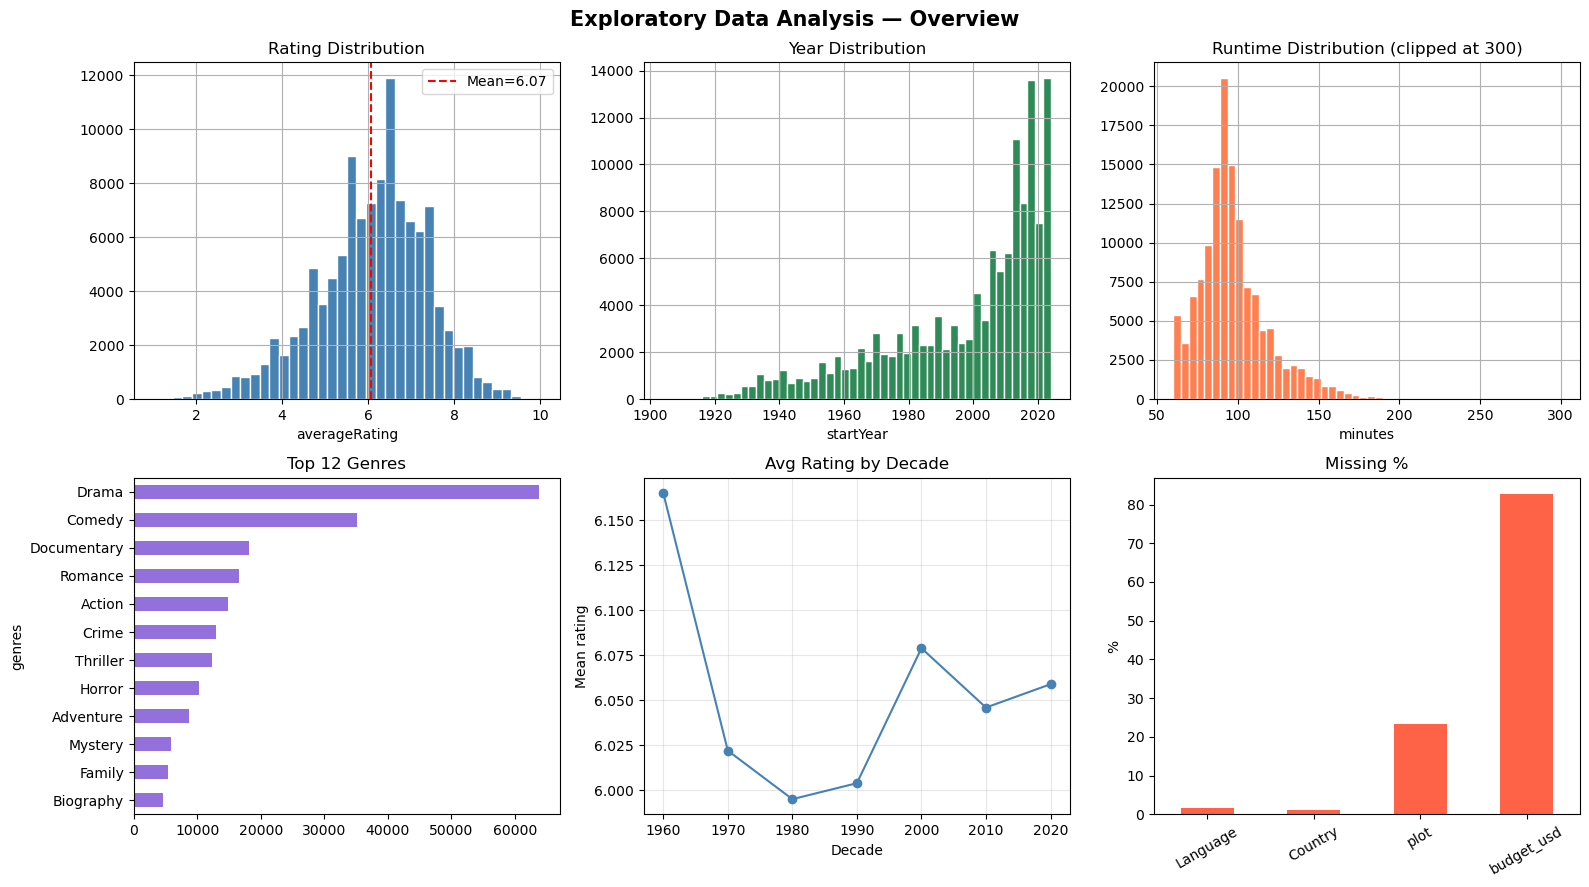

In [9]:
# ─────────────────────────────────────────────────────────────────────────
# 6.1 — Distributions, missing data, decade trends
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plt.suptitle('Exploratory Data Analysis — Overview', fontsize=15, fontweight='bold')

# Rating
df['averageRating'].dropna().hist(bins=40, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Rating Distribution')
axes[0,0].axvline(df['averageRating'].mean(), color='red', ls='--',
                  label=f'Mean={df["averageRating"].mean():.2f}')
axes[0,0].legend(); axes[0,0].set_xlabel('averageRating')

# Year
df['startYear'].dropna().hist(bins=50, ax=axes[0,1], color='seagreen', edgecolor='white')
axes[0,1].set_title('Year Distribution')
axes[0,1].set_xlabel('startYear')

# Runtime (clipped)
df['runtimeMinutes'].dropna().clip(0, 300).hist(bins=50, ax=axes[0,2], color='coral', edgecolor='white')
axes[0,2].set_title('Runtime Distribution (clipped at 300)')
axes[0,2].set_xlabel('minutes')

# Top genres
genres_s = df['genres'].dropna().str.split(',').explode().str.strip()
genres_s.value_counts().head(12).plot(kind='barh', ax=axes[1,0], color='mediumpurple')
axes[1,0].set_title('Top 12 Genres'); axes[1,0].invert_yaxis()

# Decade trend
decade_r = df.assign(decade=df['startYear'] // 10 * 10).groupby('decade')['averageRating'].mean()
decade_r = decade_r[(decade_r.index >= 1960) & (decade_r.index <= 2020)]
axes[1,1].plot(decade_r.index, decade_r.values, 'o-', color='steelblue')
axes[1,1].set_title('Avg Rating by Decade'); axes[1,1].grid(alpha=0.3)
axes[1,1].set_xlabel('Decade'); axes[1,1].set_ylabel('Mean rating')

# Missing pct
miss = df[['Language', 'Country', 'plot', 'budget_usd']].isnull().mean() * 100
miss.plot(kind='bar', ax=axes[1,2], color='tomato')
axes[1,2].set_title('Missing %'); axes[1,2].set_ylabel('%')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


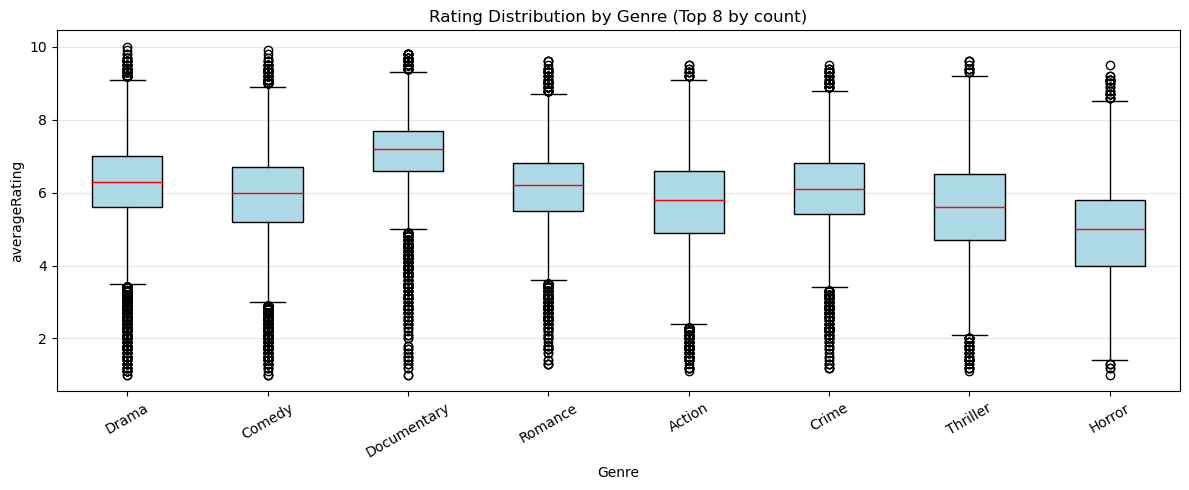


Genre rating stats:
  Drama           n=58,371  mean=6.22  std=1.13
  Comedy          n=33,267  mean=5.88  std=1.21
  Documentary     n=12,991  mean=7.15  std=1.01
  Romance         n=15,673  mean=6.11  std=1.07
  Action          n=13,959  mean=5.70  std=1.34
  Crime           n=12,384  mean=6.02  std=1.13
  Thriller        n=11,714  mean=5.55  std=1.33
  Horror          n= 9,979  mean=4.92  std=1.32


In [10]:
# ─────────────────────────────────────────────────────────────────────────
# 6.2 — Rating distribution by genre (top 8)
# Tighter, narrower distributions reveal genres the model can predict better.
# ─────────────────────────────────────────────────────────────────────────
top8 = df['genres'].dropna().str.split(',').explode().str.strip().value_counts().head(8).index
genre_data = []
for g in top8:
    mask = df['genres'].fillna('').str.contains(g, regex=False)
    genre_data.append(df.loc[mask, 'averageRating'].dropna())

plt.figure(figsize=(12, 5))
bp = plt.boxplot(genre_data, labels=top8, patch_artist=True,
                 boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
plt.ylabel('averageRating'); plt.xlabel('Genre')
plt.title('Rating Distribution by Genre (Top 8 by count)')
plt.xticks(rotation=30); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('eda_genre_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print("\nGenre rating stats:")
for g, data in zip(top8, genre_data):
    print(f"  {g:<15} n={len(data):>6,}  mean={data.mean():.2f}  std={data.std():.2f}")


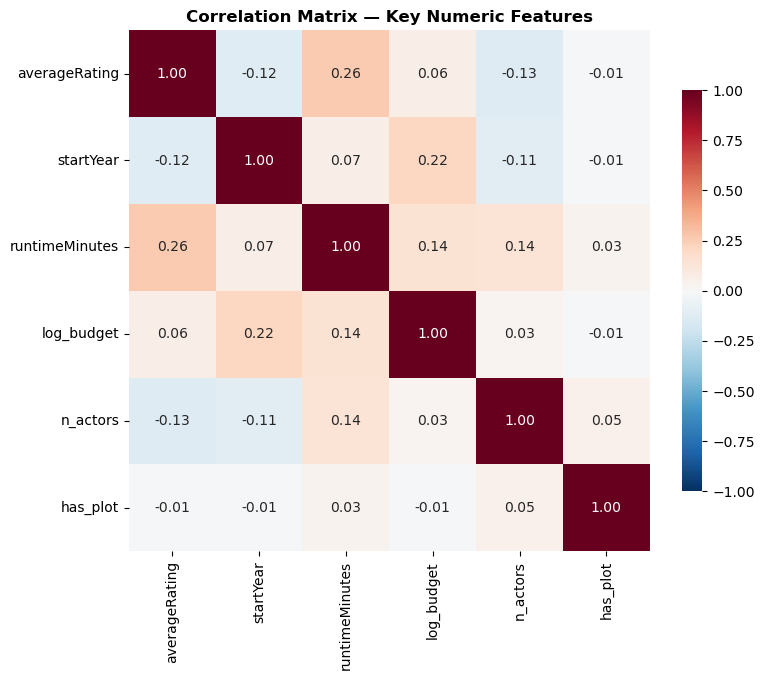


Strongest correlates of averageRating:
  runtimeMinutes     +0.264
  n_actors           -0.129
  startYear          -0.120
  log_budget         +0.063
  has_plot           -0.010


In [11]:
# ─────────────────────────────────────────────────────────────────────────
# 6.3 — Correlation heatmap of key numeric features
# Reveals multicollinearity and the strongest linear predictors of rating.
# ─────────────────────────────────────────────────────────────────────────
# Build a temporary feature snapshot (only what we need for the heatmap)
_corr_data = pd.DataFrame({
    'averageRating':  df['averageRating'],
    'startYear':      df['startYear'],
    'runtimeMinutes': df['runtimeMinutes'],
    'log_budget':     np.log1p(df['budget_usd']) if 'budget_usd' in df.columns else np.nan,
    'n_actors':       df['lead_actors_ids'].apply(lambda x: len(x) if isinstance(x, list) else 0),
    'has_plot':       df['plot'].notna().astype(float),
}).dropna()

corr = _corr_data.corr()

plt.figure(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation Matrix — Key Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStrongest correlates of averageRating:")
top_corr = corr['averageRating'].drop('averageRating').abs().sort_values(ascending=False)
for f, v in top_corr.items():
    sign = '+' if corr['averageRating'][f] > 0 else '-'
    print(f"  {f:<18} {sign}{v:.3f}")


## 7. Feature Engineering

### 7.1 Feature Functions


In [12]:
# ─────────────────────────────────────────────────────────────────────────
# Module-level enrichment dict — used by feature functions.
# Populated either from in-memory training globals OR from enrichment_globals.pkl
# (when running inference via the prof's test code).
# ─────────────────────────────────────────────────────────────────────────
_ENRICHMENT = {}


def _safe_get(name, default):
    """Return enrichment dict by name.
    Tries (1) _ENRICHMENT module-level dict, (2) Python globals(), (3) default.
    Makes prepare_data work both inside the notebook and from external code.
    """
    if name in _ENRICHMENT:
        return _ENRICHMENT[name]
    return globals().get(name, default)


def load_enrichment(pkl_path='enrichment_globals.pkl'):
    """Load enrichment globals from pickle (for use outside the notebook).
    Updates the module-level _ENRICHMENT dict so feature functions see them.
    """
    global _ENRICHMENT
    if os.path.exists(pkl_path):
        _ENRICHMENT = joblib.load(pkl_path)
        print(f"✅ Loaded {len(_ENRICHMENT)} enrichment dicts from {pkl_path}")
    return _ENRICHMENT


# ── Generic history aggregator ──────────────────────────────────────────
def _history_avg(history_dict_name, person_ids, year):
    """Mean rating of person(s) BEFORE target year (leakage-free)."""
    try:
        if not person_ids or pd.isna(year):
            return np.nan
        h = _safe_get(history_dict_name, {})
        if not h:
            return np.nan
        year = int(year)
        ratings = []
        for nc in (person_ids if isinstance(person_ids, list) else [person_ids]):
            prior = [r for y, r in h.get(nc, []) if y < year]
            if prior:
                ratings.append(float(np.mean(prior)))
        return float(np.mean(ratings)) if ratings else np.nan
    except Exception:
        return np.nan


# ── Actor features ──────────────────────────────────────────────────────
def feat_actor_hist_avg(actors, year):
    return _history_avg('actor_movie_history', actors, year)


def feat_actor_recent_avg(actors, year, k=3):
    """Mean rating of each actor's last k movies (before target year)."""
    try:
        if not actors or pd.isna(year):
            return np.nan
        h = _safe_get('actor_movie_history', {})
        if not h:
            return np.nan
        year = int(year)
        means = []
        for nc in actors:
            prior = sorted([(y, r) for y, r in h.get(nc, []) if y < year], reverse=True)
            if prior:
                means.append(float(np.mean([r for _, r in prior[:k]])))
        return float(np.mean(means)) if means else np.nan
    except Exception:
        return np.nan


def feat_actor_max(actors, year):
    """Best actor average in the cast — the 'star carrier'."""
    try:
        if not actors or pd.isna(year):
            return np.nan
        h = _safe_get('actor_movie_history', {})
        if not h:
            return np.nan
        year = int(year)
        means = []
        for nc in actors:
            prior = [r for y, r in h.get(nc, []) if y < year]
            if prior:
                means.append(float(np.mean(prior)))
        return float(max(means)) if means else np.nan
    except Exception:
        return np.nan


def feat_actor_count_avg(actors, year):
    """Average number of prior movies per cast member (experience proxy)."""
    try:
        if not actors or pd.isna(year):
            return 0.0
        h = _safe_get('actor_movie_history', {})
        if not h:
            return 0.0
        year = int(year)
        counts = [sum(1 for y, _ in h.get(nc, []) if y < year) for nc in actors]
        return float(np.mean(counts)) if counts else 0.0
    except Exception:
        return 0.0


def feat_actor_genre_avg(actors, genres_str, year):
    """Average actor rating in the SPECIFIC genres of this movie."""
    try:
        if not actors or pd.isna(genres_str) or pd.isna(year):
            return np.nan
        h = _safe_get('actor_genre_history', {})
        if not h:
            return np.nan
        year = int(year)
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]
        scores = []
        for nc in actors:
            actor_g = h.get(nc, {})
            for g in genres:
                prior = [r for y, r in actor_g.get(g, []) if y < year]
                if prior:
                    scores.append(float(np.mean(prior)))
        return float(np.mean(scores)) if scores else np.nan
    except Exception:
        return np.nan


def feat_cast_experience_std(actors, year):
    """Std-dev of cast experience — mixture of veterans + rookies is a signal."""
    try:
        if not actors or pd.isna(year) or len(actors) < 2:
            return 0.0
        h = _safe_get('actor_movie_history', {})
        if not h:
            return 0.0
        year = int(year)
        counts = [sum(1 for y, _ in h.get(nc, []) if y < year) for nc in actors]
        return float(np.std(counts)) if len(counts) >= 2 else 0.0
    except Exception:
        return 0.0


def feat_n_proven_stars(actors, year, threshold_rating=7.0, min_movies=3):
    """Count of cast members with a PROVEN track record:
    >= min_movies prior films AND historical mean >= threshold_rating.
    """
    try:
        if not actors or pd.isna(year):
            return 0.0
        h = _safe_get('actor_movie_history', {})
        if not h:
            return 0.0
        year = int(year)
        count = 0
        for nc in actors:
            ratings = [r for y, r in h.get(nc, []) if y < year]
            if len(ratings) >= min_movies and float(np.mean(ratings)) >= threshold_rating:
                count += 1
        return float(count)
    except Exception:
        return 0.0


def feat_actor_rating_std(actors, year):
    """Std of actor career ratings — high variance => unpredictable actor."""
    try:
        if not actors or pd.isna(year):
            return np.nan
        h = _safe_get('actor_movie_history', {})
        if not h:
            return np.nan
        year = int(year)
        stds = []
        for nc in actors:
            ratings = [r for y, r in h.get(nc, []) if y < year]
            if len(ratings) >= 3:
                stds.append(float(np.std(ratings)))
        return float(np.mean(stds)) if stds else np.nan
    except Exception:
        return np.nan


# ── Director features ───────────────────────────────────────────────────
def feat_director_hist_avg(director_nc, year):
    return _history_avg('director_history', director_nc, year)


def feat_director_genre_avg(dir_nc, genres_str, year):
    """Director's average rating in the SPECIFIC genres of this movie."""
    try:
        if not dir_nc or pd.isna(genres_str) or pd.isna(year):
            return np.nan
        h = _safe_get('director_genre_history', {})
        if not h:
            return np.nan
        year = int(year)
        dir_g = h.get(dir_nc, {})
        if not dir_g:
            return np.nan
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]
        scores = []
        for g in genres:
            prior = [r for y, r in dir_g.get(g, []) if y < year]
            if prior:
                scores.append(float(np.mean(prior)))
        return float(np.mean(scores)) if scores else np.nan
    except Exception:
        return np.nan


def feat_director_rating_std(dir_nc, year):
    """Std of director's career ratings — high std => unpredictable director."""
    try:
        if not dir_nc or pd.isna(year):
            return np.nan
        h = _safe_get('director_history', {})
        if not h:
            return np.nan
        year = int(year)
        ratings = [r for y, r in h.get(dir_nc, []) if y < year]
        if len(ratings) >= 3:
            return float(np.std(ratings))
        return np.nan
    except Exception:
        return np.nan


# ── Writer / Producer features ──────────────────────────────────────────
def feat_writer_hist_avg(tconst, year):
    """Average writer historical rating across all credited writers."""
    try:
        if pd.isna(year):
            return np.nan
        wm = _safe_get('writer_map', {})
        wh = _safe_get('writer_history', {})
        if not wm or not wh:
            return np.nan
        writers = wm.get(tconst, [])
        if not writers:
            return np.nan
        year = int(year)
        ratings = []
        for nc in writers:
            prior = [r for y, r in wh.get(nc, []) if y < year]
            if prior:
                ratings.append(float(np.mean(prior)))
        return float(np.mean(ratings)) if ratings else np.nan
    except Exception:
        return np.nan


def feat_producer_hist_avg(tconst, year):
    """Average producer historical rating (top 3 credited producers)."""
    try:
        if pd.isna(year):
            return np.nan
        pm = _safe_get('producer_map', {})
        ph = _safe_get('producer_history', {})
        if not pm or not ph:
            return np.nan
        producers = pm.get(tconst, [])
        if not producers:
            return np.nan
        year = int(year)
        ratings = []
        for nc in producers[:3]:
            prior = [r for y, r in ph.get(nc, []) if y < year]
            if prior:
                ratings.append(float(np.mean(prior)))
        return float(np.mean(ratings)) if ratings else np.nan
    except Exception:
        return np.nan


def feat_best_crew_rating(dir_avg, writer_avg, producer_avg):
    """Max of crew member averages — the strongest member tends to carry the film."""
    try:
        vals = [v for v in [dir_avg, writer_avg, producer_avg] if pd.notna(v)]
        return float(max(vals)) if vals else np.nan
    except Exception:
        return np.nan


# ── Genre-level features ────────────────────────────────────────────────
def feat_genre_year_trend(genres_str, year):
    """Genre rating trend slope (computed on prior years only)."""
    try:
        if pd.isna(genres_str) or pd.isna(year):
            return 0.0
        gyt = _safe_get('genre_year_trend', {})
        if not gyt:
            return 0.0
        year = int(year)
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]
        vals = [gyt.get((g, min(year, 2030)), 0.0) for g in genres]
        return float(np.mean(vals)) if vals else 0.0
    except Exception:
        return 0.0


def feat_genre_year_avg_rolling(genres_str, year):
    """5-year rolling genre rating average (prior years only)."""
    try:
        if pd.isna(genres_str) or pd.isna(year):
            return 0.0
        gyar = _safe_get('genre_year_avg_rolling', {})
        if not gyar:
            return 0.0
        year = int(year)
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]
        vals = [gyar.get((g, min(year, 2030)), 0.0) for g in genres]
        return float(np.mean(vals)) if vals else 0.0
    except Exception:
        return 0.0


def feat_runtime_genre_deviation(runtime, genres_str):
    """Movie runtime minus median runtime for its genres."""
    try:
        if pd.isna(runtime) or pd.isna(genres_str):
            return 0.0
        grm = _safe_get('genre_runtime_median', {})
        gmed = _safe_get('GLOBAL_MEDIAN_RUNTIME', 100.0)
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]
        medians = [grm.get(g, gmed) for g in genres]
        med = np.mean(medians) if medians else gmed
        return float(runtime - med)
    except Exception:
        return 0.0


# ── Franchise features ──────────────────────────────────────────────────
def _franchise_lookup(title, year):
    """Return (filtered_prior_entries) for the franchise of this title.
    Tries the detected stem first, then falls back to the normalized full title.
    Filters strictly to year < target_year (leakage-free).
    """
    if not isinstance(title, str) or pd.isna(year):
        return []
    h = _safe_get('franchise_history', {})
    if not h:
        return []
    year = int(year)
    # Try stem first
    stem = extract_franchise_stem(title)
    if stem and stem in h:
        return [r for y, r in h[stem] if y < year]
    # Fall back to full normalized title (catches the franchise "parent")
    norm = normalize_title_for_match(title)
    if norm and norm in h:
        return [r for y, r in h[norm] if y < year]
    return []


def feat_franchise_avg(title, year):
    """Mean rating of prior franchise entries (NaN if no prior entries)."""
    try:
        prior = _franchise_lookup(title, year)
        return float(np.mean(prior)) if prior else np.nan
    except Exception:
        return np.nan


def feat_franchise_count(title, year):
    """Number of prior franchise entries (0 if none / not a franchise)."""
    try:
        prior = _franchise_lookup(title, year)
        return float(len(prior))
    except Exception:
        return 0.0


def feat_is_franchise(title, year):
    """Binary: 1 if any prior franchise entry exists, else 0."""
    try:
        prior = _franchise_lookup(title, year)
        return 1.0 if prior else 0.0
    except Exception:
        return 0.0


# ── Director × cast collaboration ───────────────────────────────────────
def feat_collab_dir_actor_avg(dir_nc, actors, year):
    """Avg rating of prior movies where the director & one of the listed
    actors worked together (year < target_year). NaN if no collaboration."""
    try:
        if not dir_nc or not actors or pd.isna(year):
            return np.nan
        h = _safe_get('dir_actor_collab', {})
        if not h:
            return np.nan
        year = int(year)
        ratings = []
        for actor_nc in (actors if isinstance(actors, list) else [actors]):
            prior = [r for y, r in h.get((dir_nc, actor_nc), []) if y < year]
            if prior:
                ratings.extend(prior)
        return float(np.mean(ratings)) if ratings else np.nan
    except Exception:
        return np.nan


def feat_collab_dir_actor_count(dir_nc, actors, year):
    """Total number of prior dir-actor collaborations across the cast."""
    try:
        if not dir_nc or not actors or pd.isna(year):
            return 0.0
        h = _safe_get('dir_actor_collab', {})
        if not h:
            return 0.0
        year = int(year)
        count = 0
        for actor_nc in (actors if isinstance(actors, list) else [actors]):
            count += sum(1 for y, _ in h.get((dir_nc, actor_nc), []) if y < year)
        return float(count)
    except Exception:
        return 0.0


def feat_collab_dir_writer_avg(dir_nc, tconst, year):
    """Avg rating of prior movies where the director & any of the writers
    on this movie worked together (year < target_year)."""
    try:
        if not dir_nc or pd.isna(year):
            return np.nan
        h = _safe_get('dir_writer_collab', {})
        wm = _safe_get('writer_map', {})
        if not h or not wm:
            return np.nan
        year = int(year)
        writers = wm.get(tconst, [])
        if not writers:
            return np.nan
        ratings = []
        for writer_nc in writers:
            prior = [r for y, r in h.get((dir_nc, writer_nc), []) if y < year]
            if prior:
                ratings.extend(prior)
        return float(np.mean(ratings)) if ratings else np.nan
    except Exception:
        return np.nan


print("✅ Feature functions defined")


✅ Feature functions defined


### 7.2 `prepare_data()` Function


In [13]:
def prepare_data(df_in: pd.DataFrame) -> pd.DataFrame:
    """Prepare features for IMDb rating prediction.

    Args:
        df_in: DataFrame with raw columns (tconst, primaryTitle, startYear,
               runtimeMinutes, genres, lead_actors_ids, Language, Country,
               plot, budget, certification, release_month, ...).

    Returns:
        DataFrame of engineered features (71 columns) ready for model.predict().
    """
    # Auto-load enrichment dicts if needed (external execution support)
    if not _ENRICHMENT and 'actor_movie_history' not in globals():
        if os.path.exists('enrichment_globals.pkl'):
            load_enrichment('enrichment_globals.pkl')

    d = df_in.copy()

    # ── 1. Basic cleaning & type coercion ────────────────────────────────
    d.replace(['Not Found', 'not found', 'N/A', 'NA', 'None', 'none', '\\N', ''],
              np.nan, inplace=True)
    d['startYear']      = pd.to_numeric(d.get('startYear'), errors='coerce')
    d['runtimeMinutes'] = pd.to_numeric(d.get('runtimeMinutes'), errors='coerce')

    # ── 2. Parse actors / genres / plot ──────────────────────────────────
    if 'lead_actors_ids' not in d.columns:
        d['lead_actors_ids'] = None
    d['lead_actors_ids'] = d['lead_actors_ids'].apply(
        lambda v: v if isinstance(v, list) else parse_actor_list(v))
    if 'genres' not in d.columns:
        d['genres'] = np.nan
    d['genres'] = d['genres'].apply(parse_genres)
    d['plot']   = d.get('plot', pd.Series(index=d.index)).apply(clean_plot)

    # ── 3. Genre one-hot (20 genres) ─────────────────────────────────────
    for genre in TOP_GENRES:
        col = 'g_' + genre.replace('-', '_').replace(' ', '_')
        d[col] = d['genres'].apply(
            lambda g, _g=genre: 1.0 if pd.notna(g) and _g in str(g).split(',') else 0.0)

    # ── 4. Actor features ────────────────────────────────────────────────
    d['feat_actor_hist_avg']   = d.apply(lambda r: feat_actor_hist_avg(r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_actor_recent_avg'] = d.apply(lambda r: feat_actor_recent_avg(r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_actor_max']        = d.apply(lambda r: feat_actor_max(r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_actor_count_avg']  = d.apply(lambda r: feat_actor_count_avg(r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_actor_genre_avg']  = d.apply(lambda r: feat_actor_genre_avg(r['lead_actors_ids'], r['genres'], r['startYear']), axis=1)
    d['feat_cast_exp_std']     = d.apply(lambda r: feat_cast_experience_std(r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_actor_rating_std'] = d.apply(lambda r: feat_actor_rating_std(r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_n_proven_stars']   = d.apply(lambda r: feat_n_proven_stars(r['lead_actors_ids'], r['startYear']), axis=1)

    # ── 5. Director features ─────────────────────────────────────────────
    def get_primary_dir(r):
        try:
            dir_ids = r.get('directors_ids', None)
            if isinstance(dir_ids, list) and dir_ids:
                return dir_ids[0]
            if isinstance(dir_ids, str) and dir_ids:
                ids = [x.strip() for x in dir_ids.split(',')
                       if re.match(r'^nm\d+$', x.strip())]
                return ids[0] if ids else None
            tc = r.get('tconst', None)
            if tc is not None:
                dpm = _safe_get('dir_primary_map', {})
                if dpm:
                    return dpm.get(tc, None)
            return None
        except Exception:
            return None

    d['_dir_nc'] = d.apply(get_primary_dir, axis=1)
    d['feat_director_hist_avg']   = d.apply(lambda r: feat_director_hist_avg(r['_dir_nc'], r['startYear']), axis=1)
    d['feat_director_genre_avg']  = d.apply(lambda r: feat_director_genre_avg(r['_dir_nc'], r['genres'], r['startYear']), axis=1)
    d['feat_director_rating_std'] = d.apply(lambda r: feat_director_rating_std(r['_dir_nc'], r['startYear']), axis=1)

    # ── 6. Writer / producer features ────────────────────────────────────
    d['feat_writer_hist_avg']   = d.apply(lambda r: feat_writer_hist_avg(r.get('tconst'), r['startYear']), axis=1)
    d['feat_producer_hist_avg'] = d.apply(lambda r: feat_producer_hist_avg(r.get('tconst'), r['startYear']), axis=1)
    d['feat_best_crew']         = d.apply(lambda r: feat_best_crew_rating(
        r['feat_director_hist_avg'], r['feat_writer_hist_avg'], r['feat_producer_hist_avg']), axis=1)

    # ── 7. Genre-level features ──────────────────────────────────────────
    d['feat_genre_year_trend']   = d.apply(lambda r: feat_genre_year_trend(r['genres'], r['startYear']), axis=1)
    d['feat_genre_year_rolling'] = d.apply(lambda r: feat_genre_year_avg_rolling(r['genres'], r['startYear']), axis=1)
    d['feat_runtime_genre_dev']  = d.apply(lambda r: feat_runtime_genre_deviation(r['runtimeMinutes'], r['genres']), axis=1)

    # ── 7b. Franchise features (from title-based detection) ──────────────
    d['feat_franchise_avg']   = d.apply(lambda r: feat_franchise_avg(r.get('primaryTitle'), r['startYear']), axis=1)
    d['feat_franchise_count'] = d.apply(lambda r: feat_franchise_count(r.get('primaryTitle'), r['startYear']), axis=1)
    d['feat_is_franchise']    = d.apply(lambda r: feat_is_franchise(r.get('primaryTitle'), r['startYear']), axis=1)

    # ── 7c. Director × cast collaboration features ───────────────────────
    d['feat_collab_dir_actor_avg']   = d.apply(
        lambda r: feat_collab_dir_actor_avg(r['_dir_nc'], r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_collab_dir_actor_count'] = d.apply(
        lambda r: feat_collab_dir_actor_count(r['_dir_nc'], r['lead_actors_ids'], r['startYear']), axis=1)
    d['feat_collab_dir_writer_avg']  = d.apply(
        lambda r: feat_collab_dir_writer_avg(r['_dir_nc'], r.get('tconst'), r['startYear']), axis=1)

    # ── 8. n_actors and derived ──────────────────────────────────────────
    d['n_actors'] = d['lead_actors_ids'].apply(
        lambda a: float(len(a)) if isinstance(a, list) else 0.0)
    d['n_actors_sq'] = d['n_actors'] ** 2
    g_doc = d.get('g_Documentary', pd.Series(0.0, index=d.index))
    d['is_doc_or_no_cast'] = ((g_doc == 1) | (d['n_actors'] == 0)).astype(float)

    # ── 9. Runtime ───────────────────────────────────────────────────────
    d['log_runtime'] = np.log1p(d['runtimeMinutes'])

    # ── 10. Budget features ──────────────────────────────────────────────
    # budget_usd is created during cleaning from raw 'budget'. At inference
    # time (e.g. prof's held-out test set), only raw 'budget' may exist —
    # parse it on the fly.
    if 'budget_usd' not in d.columns or d['budget_usd'].isna().all():
        if 'budget' in d.columns:
            try:
                d['budget_usd'] = d['budget'].apply(parse_budget_to_usd_millions)
            except NameError:
                d['budget_usd'] = np.nan
        else:
            d['budget_usd'] = np.nan
    _bud = pd.to_numeric(d.get('budget_usd', pd.Series(np.nan, index=d.index)), errors='coerce')
    d['log_budget']        = np.log1p(_bud.where(_bud > 0))   # NaN → imputed
    d['is_missing_budget'] = _bud.isna().astype(float)

    # ── 11. Time features ────────────────────────────────────────────────
    d['years_since_2000'] = d['startYear'] - 2000.0

    # ── 12. Language / Country ───────────────────────────────────────────
    d['is_english'] = d.get('Language', pd.Series(index=d.index)).fillna('').apply(
        lambda x: 1.0 if 'English' in str(x) else 0.0)
    d['is_us'] = d.get('Country', pd.Series(index=d.index)).fillna('').apply(
        lambda x: 1.0 if any(k in str(x) for k in ['United States', 'USA']) else 0.0)
    # Target-encoded primary language/country
    d['lang_primary'] = d.get('Language', pd.Series(index=d.index)).fillna('_unknown_').apply(
        lambda x: str(x).split(',')[0].strip() if pd.notna(x) else '_unknown_')
    d['country_primary'] = d.get('Country', pd.Series(index=d.index)).fillna('_unknown_').apply(
        lambda x: str(x).split(',')[0].strip() if pd.notna(x) else '_unknown_')

    # ── 13. Misc features ────────────────────────────────────────────────
    d['has_plot']        = d['plot'].notna().astype(float)
    d['plot_word_count'] = d['plot'].fillna('').astype(str).str.split().apply(len).astype(float)
    d['n_genres']        = d['genres'].apply(
        lambda x: float(len([g for g in str(x).split(',') if g.strip()])) if pd.notna(x) else 0.0)

    # ── 14. Title-based features ─────────────────────────────────────────
    _t = d.get('primaryTitle', pd.Series('', index=d.index)).fillna('').astype(str)
    d['title_length']     = _t.str.len().astype(float)
    d['title_word_count'] = _t.str.split().apply(len).astype(float)
    d['title_has_colon']  = _t.str.contains(':', regex=False).astype(float)
    d['title_has_number'] = _t.str.contains(r'\d', regex=True).astype(float)

    # ── 15. (n_markets removed — see leakage notes; was post-release info) ──

    # ── 15b. Studio (from TMDB) ──────────────────────────────────────────
    # tmdb_is_major is computed during enrichment but wasn't being used as a
    # feature. Major-studio movies systematically rate differently.
    d['is_major_studio'] = pd.to_numeric(
        d.get('tmdb_is_major', 0), errors='coerce').fillna(0.0).astype(float)

    # ── 16. Content rating (MPAA) ────────────────────────────────────────
    def _norm_cert(c):
        if pd.isna(c):
            return '_unknown_'
        c = str(c).strip().upper()
        mapping = {
            'G': 'G', 'TV-G': 'G', 'TV-Y': 'G', 'TV-Y7': 'G', 'APPROVED': 'G',
            'PG': 'PG', 'TV-PG': 'PG',
            'PG-13': 'PG-13', 'TV-14': 'PG-13', 'M': 'PG-13',
            'R': 'R', 'TV-MA': 'R', 'NC-17': 'R', 'X': 'R',
            'UNRATED': '_unknown_', 'NOT RATED': '_unknown_', '': '_unknown_',
        }
        return mapping.get(c, '_unknown_')
    d['content_rating'] = d.get('certification', pd.Series(index=d.index)).apply(_norm_cert)

    # ── 17. Release season ───────────────────────────────────────────────
    def _season(m):
        try:
            m = int(m)
            if m in (11, 12): return 'awards'     # Nov-Dec: prestige
            if m in (6, 7, 8): return 'summer'    # Jun-Aug: blockbusters
            if m in (1, 2):    return 'dump'      # Jan-Feb: dump months
            return 'regular'
        except Exception:
            return '_unknown_'
    d['release_season']   = d.get('release_month', pd.Series(index=d.index)).apply(_season)
    d['has_release_date'] = d.get('release_month', pd.Series(index=d.index)).notna().astype(float)

    # ── 18. Missing indicators ───────────────────────────────────────────
    d['is_missing_actor_hist'] = d['feat_actor_hist_avg'].isna().astype(float)
    d['is_missing_director']   = d['feat_director_hist_avg'].isna().astype(float)
    d['is_missing_writer']     = d['feat_writer_hist_avg'].isna().astype(float)

    # ── 19. Interaction features (kept only high-importance ones) ────────
    rt = d['runtimeMinutes'].fillna(0)
    d['horror_x_runtime']      = d.get('g_Horror', pd.Series(0.0, index=d.index)) * rt
    d['doc_x_runtime']         = g_doc * rt
    d['n_actors_x_rt']         = d['n_actors'] * rt
    d['actor_x_director']      = d['feat_actor_hist_avg'].fillna(0) * d['feat_director_hist_avg'].fillna(0)
    d['actor_x_genre_rolling'] = d['feat_actor_hist_avg'].fillna(0) * d['feat_genre_year_rolling'].fillna(0)
    d['writer_x_director']     = d['feat_writer_hist_avg'].fillna(0) * d['feat_director_hist_avg'].fillna(0)

    # ── 19b. Polynomial + crossed features (give the LINEAR EN access to non-linearity) ──
    # EN can only learn linear relationships; these crosses let it capture:
    # - quadratic talent effects (a 9.0-avg actor is much more than 1.5× as valuable as 6.0)
    # - star × budget synergy (Spielberg + $100M ≠ Spielberg's avg + $100M's avg)
    # - crew-era fit (a great team in a hot genre period vs cold period)
    _af = d['feat_actor_hist_avg'].fillna(0)
    _df = d['feat_director_hist_avg'].fillna(0)
    _lb = d['log_budget'].fillna(0)
    _gr = d['feat_genre_year_rolling'].fillna(0)
    d['feat_actor_sq']         = _af ** 2
    d['feat_director_sq']      = _df ** 2
    d['actor_x_budget']        = _af * _lb
    d['director_x_budget']     = _df * _lb
    d['best_crew_x_genre']     = d['feat_best_crew'].fillna(0) * _gr
    d['n_actors_x_actor_avg']  = d['n_actors'] * _af
    d['actor_recent_x_hist']   = d['feat_actor_recent_avg'].fillna(0) * _af
    d['actor_max_x_genre']     = d['feat_actor_max'].fillna(0) * _gr

    # ── 20. Plot text for TF-IDF ─────────────────────────────────────────
    d['plot_final'] = d['plot'].fillna('').astype(str)

    # ── 21. Select & assemble output ─────────────────────────────────────
    genre_cols = ['g_' + g.replace('-', '_').replace(' ', '_') for g in TOP_GENRES]

    base_cols = [
        'startYear', 'years_since_2000',
        'runtimeMinutes', 'log_runtime',
        'log_budget', 'is_missing_budget',
        'feat_actor_hist_avg', 'feat_actor_recent_avg', 'feat_actor_max',
        'feat_actor_count_avg', 'feat_actor_genre_avg', 'feat_cast_exp_std',
        'feat_actor_rating_std', 'feat_n_proven_stars',
        'feat_director_hist_avg', 'feat_director_genre_avg', 'feat_director_rating_std',
        'feat_writer_hist_avg', 'feat_producer_hist_avg', 'feat_best_crew',
        'feat_genre_year_trend', 'feat_genre_year_rolling', 'feat_runtime_genre_dev',
        'feat_franchise_avg', 'feat_franchise_count', 'feat_is_franchise',
        'feat_collab_dir_actor_avg', 'feat_collab_dir_actor_count', 'feat_collab_dir_writer_avg',
        'n_actors', 'n_actors_sq', 'is_doc_or_no_cast',
        'is_english', 'is_us', 'is_major_studio',
        'has_plot', 'plot_word_count', 'n_genres', 'has_release_date',
        'title_length', 'title_word_count',
        'title_has_colon', 'title_has_number',
        'is_missing_actor_hist', 'is_missing_director', 'is_missing_writer',
        'horror_x_runtime', 'doc_x_runtime',
        'n_actors_x_rt', 'actor_x_director', 'actor_x_genre_rolling',
        'writer_x_director',
        # Polynomial / interaction features added for EN
        'feat_actor_sq', 'feat_director_sq',
        'actor_x_budget', 'director_x_budget',
        'best_crew_x_genre', 'n_actors_x_actor_avg',
        'actor_recent_x_hist', 'actor_max_x_genre',
    ]

    NUMERIC_COLS = [c for c in base_cols + genre_cols if c in d.columns]
    TEXT_COL = 'plot_final'
    CAT_COLS = ['lang_primary', 'country_primary', 'content_rating', 'release_season']

    out = pd.DataFrame(index=d.index)
    out[NUMERIC_COLS] = d[NUMERIC_COLS].astype(float)
    out[TEXT_COL] = d[TEXT_COL].astype(str)
    for c in CAT_COLS:
        out[c] = d[c].astype(str) if c in d.columns else '_unknown_'

    # Align to trained columns if known (preserves column order at inference)
    trained_cols = globals().get('TRAINED_COLUMNS', None)
    if trained_cols is not None:
        for c in trained_cols:
            if c not in out.columns:
                if c in CAT_COLS:
                    out[c] = '_unknown_'
                elif c == TEXT_COL:
                    out[c] = ''
                else:
                    out[c] = 0.0
        out = out[trained_cols]

    return out.reset_index(drop=True)


print("✅ prepare_data() defined")


✅ prepare_data() defined


### 7.3 Tests for `prepare_data()`


In [14]:
# ─────────────────────────────────────────────────────────────────────────
# Test 1: Single row (explicit assignment requirement)
# ─────────────────────────────────────────────────────────────────────────
print("Test 1: prepare_data on single row...")
_X1 = prepare_data(df.head(1))
assert _X1.shape[0] == 1, f"Expected 1 row, got {_X1.shape[0]}"
print(f"  ✅ Single row → shape={_X1.shape}")

# ─────────────────────────────────────────────────────────────────────────
# Test 2: Batch (5 rows)
# ─────────────────────────────────────────────────────────────────────────
print("Test 2: prepare_data on 5 rows...")
_X5 = prepare_data(df.head(5))
assert _X5.shape[0] == 5
print(f"  ✅ 5 rows → shape={_X5.shape}")

# ─────────────────────────────────────────────────────────────────────────
# Test 3: Large batch (200 rows) — proves scalability
# ─────────────────────────────────────────────────────────────────────────
print("Test 3: prepare_data on 200 rows...")
_X200 = prepare_data(df.head(200))
assert _X200.shape[0] == 200
print(f"  ✅ 200 rows → shape={_X200.shape}")

# ─────────────────────────────────────────────────────────────────────────
# Test 4: No leakage columns
# ─────────────────────────────────────────────────────────────────────────
print("Test 4: No leakage columns in output...")
for col in ['averageRating', 'numVotes', 'BoxOffice']:
    assert col not in _X200.columns, f"❌ LEAKAGE: {col}"
print(f"  ✅ Forbidden columns absent")

# ─────────────────────────────────────────────────────────────────────────
# Test 5: Determinism (same input → same output)
# ─────────────────────────────────────────────────────────────────────────
print("Test 5: Determinism check...")
_X5_again = prepare_data(df.head(5))
assert _X5.equals(_X5_again), "❌ Not deterministic!"
print(f"  ✅ Same input produces same output")

print("\n✅ All prepare_data tests passed")


Test 1: prepare_data on single row...
  ✅ Single row → shape=(1, 85)
Test 2: prepare_data on 5 rows...
  ✅ 5 rows → shape=(5, 85)
Test 3: prepare_data on 200 rows...
  ✅ 200 rows → shape=(200, 85)
Test 4: No leakage columns in output...
  ✅ Forbidden columns absent
Test 5: Determinism check...
  ✅ Same input produces same output

✅ All prepare_data tests passed


### 7.4 Build Feature Matrix and Target Vector

In [15]:
# Filter to movies with valid target AND year >= 2000 (where signal is reliable)
df_model = df.dropna(subset=['averageRating']).copy()
df_model = df_model[df_model['startYear'] >= 2000].reset_index(drop=True)
print(f"Modeling set: {len(df_model):,} rows (year >= 2000)")

# ─────────────────────────────────────────────────────────────────────────
# Cache the prepared X matrix on disk. First run computes it (~10 min),
# subsequent runs load it instantly. Delete the .joblib file if you change
# prepare_data() or the dataset itself.
# ─────────────────────────────────────────────────────────────────────────
X_CACHE = 'prepared_X.joblib'
if os.path.exists(X_CACHE):
    print(f"📥 Loading cached X from {X_CACHE}...")
    X = joblib.load(X_CACHE)
    # Safety check: if size doesn't match df_model, cache is stale
    if len(X) != len(df_model):
        print(f"   ⚠️  Cache size mismatch ({len(X)} vs {len(df_model)}); recomputing")
        X = prepare_data(df_model)
        joblib.dump(X, X_CACHE)
    else:
        print(f"   ✅ Cache hit — delete {X_CACHE} to force recompute")
else:
    print("Running prepare_data on full set (slow, only on first run)...")
    X = prepare_data(df_model)
    joblib.dump(X, X_CACHE)
    print(f"   ✅ X saved to {X_CACHE}")

y = df_model['averageRating'].astype(float).values

print(f"\nX shape: {X.shape} | y len: {len(y):,}")
for col in ['averageRating', 'numVotes', 'BoxOffice']:
    assert col not in X.columns, f"❌ LEAKAGE: {col}"
print("✅ No data leakage in feature matrix")


Modeling set: 69,356 rows (year >= 2000)
Running prepare_data on full set (slow, only on first run)...
   ✅ X saved to prepared_X.joblib

X shape: (69356, 85) | y len: 69,356
✅ No data leakage in feature matrix


## 8. Modeling

### 8.1 CV Framework 10-fold cross-validation


In [16]:
# ─────────────────────────────────────────────────────────────────────────
# Identify column types from X
# ─────────────────────────────────────────────────────────────────────────
TEXT_COL     = 'plot_final'
CAT_COLS     = ['lang_primary', 'country_primary', 'content_rating', 'release_season']
NUMERIC_COLS = [c for c in X.columns if c not in [TEXT_COL] + CAT_COLS]

# Frozen column order — written to enrichment_globals.pkl for inference
TRAINED_COLUMNS = list(X.columns)

print(f"Numeric: {len(NUMERIC_COLS)} | Text: 1 | Categorical: {len(CAT_COLS)}")
print(f"Total features entering pipeline: {len(X.columns)}")


def build_preprocessor(tfidf_max=3000, svd_n=50):
    """Build ColumnTransformer with three branches:
       (1) numeric:     impute median → standard scale
       (2) text:        TF-IDF (1-2 grams) → SVD
       (3) categorical: target-encode (cross-fitted)
    """
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    text_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=tfidf_max, ngram_range=(1, 2),
                                  min_df=5, max_df=0.95, sublinear_tf=True)),
        ('svd',   TruncatedSVD(n_components=svd_n, random_state=RANDOM_STATE)),
    ])
    cat_pipe = Pipeline([
        ('te', TargetEncoder(smooth='auto', target_type='continuous',
                             random_state=RANDOM_STATE)),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, NUMERIC_COLS),
        ('txt', text_pipe,    TEXT_COL),
        ('cat', cat_pipe,     CAT_COLS),
    ], remainder='drop')


kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


def evaluate_cv(pipeline, X_df, y_arr, label='Model', n_jobs=-1):
    """Run 10-fold CV and report RMSE/MAE/R² (mean + std)."""
    cv_results = cross_validate(
        pipeline, X_df, y_arr, cv=kf,
        scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
        return_train_score=False, n_jobs=n_jobs,
    )
    rmse = -cv_results['test_neg_root_mean_squared_error']
    mae  = -cv_results['test_neg_mean_absolute_error']
    r2   = cv_results['test_r2']

    print(f"\n{'═' * 50}")
    print(f"  {label} — 10-Fold CV")
    print(f"{'═' * 50}")
    print(f"  RMSE : {rmse.mean():.4f} ± {rmse.std():.4f}")
    print(f"  MAE  : {mae.mean():.4f} ± {mae.std():.4f}")
    print(f"  R²   : {r2.mean():.4f} ± {r2.std():.4f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2,
            'rmse_mean': rmse.mean(), 'mae_mean': mae.mean(), 'r2_mean': r2.mean()}


def cv_train_and_predict(pipeline, X_df, y_arr, label='Model', n_jobs=-1):
    """SINGLE-PASS 10-fold CV: returns per-fold metrics AND OOF predictions.

    Equivalent to running evaluate_cv() + cross_val_predict() but in a single
    pass — cuts wall time roughly in half (matters most for Random Forest).

    n_jobs=-1 runs folds in parallel (use for fast estimators like EN).
    n_jobs=1  runs folds sequentially (use for RF/GB, which parallelize inside).
    """
    from sklearn.base import clone
    from joblib import Parallel, delayed
    import time

    def _fit_one(fold_i, train_idx, test_idx):
        X_tr, X_te = X_df.iloc[train_idx], X_df.iloc[test_idx]
        y_tr, y_te = y_arr[train_idx], y_arr[test_idx]
        model = clone(pipeline)
        t0 = time.time()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        return fold_i, test_idx, y_pred, y_te, time.time() - t0

    t_start = time.time()
    print(f"\n{label} — running 10-fold CV (single pass)...", flush=True)
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_fit_one)(i, tr, te)
        for i, (tr, te) in enumerate(kf.split(X_df), start=1)
    )

    oof = np.zeros(len(y_arr))
    fold_rmse, fold_mae, fold_r2 = [], [], []
    for fold_i, test_idx, y_pred, y_te, dur in sorted(results):
        oof[test_idx] = y_pred
        fold_rmse.append(np.sqrt(mean_squared_error(y_te, y_pred)))
        fold_mae.append(mean_absolute_error(y_te, y_pred))
        fold_r2.append(r2_score(y_te, y_pred))
        print(f"  Fold {fold_i:2d}/10: RMSE={fold_rmse[-1]:.4f}  ({dur:.0f}s)", flush=True)

    rmse, mae, r2 = np.array(fold_rmse), np.array(fold_mae), np.array(fold_r2)
    total_min = (time.time() - t_start) / 60
    print(f"\n{'═' * 50}")
    print(f"  {label} — 10-Fold CV  (total {total_min:.1f} min)")
    print(f"{'═' * 50}")
    print(f"  RMSE : {rmse.mean():.4f} ± {rmse.std():.4f}")
    print(f"  MAE  : {mae.mean():.4f} ± {mae.std():.4f}")
    print(f"  R²   : {r2.mean():.4f} ± {r2.std():.4f}")
    return ({'rmse': rmse, 'mae': mae, 'r2': r2,
             'rmse_mean': rmse.mean(), 'mae_mean': mae.mean(), 'r2_mean': r2.mean()},
            oof)


print("✅ CV framework ready")


Numeric: 80 | Text: 1 | Categorical: 4
Total features entering pipeline: 85
✅ CV framework ready


### 8.2 Elastic Net — Hyperparameter Tuning + Target Transformation


In [17]:
# ─────────────────────────────────────────────────────────────────────────
# Target transformation: y in [1,10] → logit space (and inverse).
# Defined at module level so joblib can serialize TransformedTargetRegressor.
# ─────────────────────────────────────────────────────────────────────────
def y_to_logit(y_arr):
    """Map y ∈ [1, 10] → logit space (-∞, +∞). Clipped to avoid infinities."""
    y_arr = np.asarray(y_arr, dtype=float)
    y_clipped = np.clip(y_arr, 1.001, 9.999)
    p = (y_clipped - 1.0) / 9.0
    return np.log(p / (1.0 - p))


def y_from_logit(y_logit):
    """Inverse: logit space → [1, 10]. Clipped just in case."""
    y_logit = np.asarray(y_logit, dtype=float)
    p = 1.0 / (1.0 + np.exp(-y_logit))
    return np.clip(p * 9.0 + 1.0, 1.0, 10.0)


# Sanity check the transformation
_test_y = np.array([1.5, 5.5, 8.5])
assert np.allclose(y_from_logit(y_to_logit(_test_y)), _test_y, atol=1e-6), \
    "Target transformation round-trip failed"
print(f"✅ Target transformation verified (round-trip OK)")
print(f"   y={_test_y} → logit={y_to_logit(_test_y).round(3)} → back={y_from_logit(y_to_logit(_test_y)).round(3)}")


✅ Target transformation verified (round-trip OK)
   y=[1.5 5.5 8.5] → logit=[-2.833  0.     1.609] → back=[1.5 5.5 8.5]


In [18]:
# ─────────────────────────────────────────────────────────────────────────
# Optuna search for Elastic Net (alpha, l1_ratio, tfidf_max, svd_n)
# Runs only if RUN_OPTUNA=True. Otherwise we use the cached best params.
# ─────────────────────────────────────────────────────────────────────────
EN_BEST_PARAMS = {
    'alpha':     0.0001283077266440877,
    'l1_ratio':  0.3700903968854148,
    'tfidf_max': 3000,
    'svd_n':     80,
}

if RUN_OPTUNA:
    print("🔬 Running Optuna for Elastic Net (~3 hours)...")
    inner_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def en_objective(trial):
        alpha     = trial.suggest_float('alpha', 1e-5, 1.0, log=True)
        l1_ratio  = trial.suggest_float('l1_ratio', 0.0, 1.0)
        tfidf_max = trial.suggest_categorical('tfidf_max', [1500, 3000, 5000])
        svd_n     = trial.suggest_categorical('svd_n', [30, 50, 80, 120])

        pre = build_preprocessor(tfidf_max=tfidf_max, svd_n=svd_n)
        pipe = Pipeline([
            ('pre', pre),
            ('model', TransformedTargetRegressor(
                regressor=ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                                      max_iter=10000, random_state=RANDOM_STATE),
                func=y_to_logit,
                inverse_func=y_from_logit,
                check_inverse=False,
            )),
        ])
        scores = cross_val_score(pipe, X, y, cv=inner_kf,
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
        return -scores.mean()

    en_study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    en_study.optimize(en_objective, n_trials=50, show_progress_bar=True)
    EN_BEST_PARAMS = en_study.best_params
    print(f"\n🏆 Best EN params: {EN_BEST_PARAMS}")
    print(f"   Best RMSE (inner 5-fold): {en_study.best_value:.4f}")
else:
    print(f"⏭️  Using cached EN best params (RUN_OPTUNA=False)")
    print(f"   Params: {EN_BEST_PARAMS}")
    print(f"   (Set RUN_OPTUNA=True in cell 1 to re-run the search.)")


⏭️  Using cached EN best params (RUN_OPTUNA=False)
   Params: {'alpha': 0.0001283077266440877, 'l1_ratio': 0.3700903968854148, 'tfidf_max': 3000, 'svd_n': 80}
   (Set RUN_OPTUNA=True in cell 1 to re-run the search.)


In [19]:
# ─────────────────────────────────────────────────────────────────────────
# Build final Elastic Net pipeline → evaluate on 10-fold CV
# The TransformedTargetRegressor wraps EN so it fits in logit space
# but `.predict()` returns values in the original [1,10] scale.
# ─────────────────────────────────────────────────────────────────────────
en_preprocessor = build_preprocessor(
    tfidf_max=EN_BEST_PARAMS['tfidf_max'],
    svd_n=EN_BEST_PARAMS['svd_n'],
)
en_pipeline = Pipeline([
    ('pre',   en_preprocessor),
    ('model', TransformedTargetRegressor(
        regressor=ElasticNet(
            alpha=EN_BEST_PARAMS['alpha'],
            l1_ratio=EN_BEST_PARAMS['l1_ratio'],
            max_iter=10000,
            random_state=RANDOM_STATE,
        ),
        func=y_to_logit,
        inverse_func=y_from_logit,
        check_inverse=False,
    )),
])

# Single-pass CV: returns metrics + OOF predictions in ONE 10-fold sweep
# (was previously two separate passes). n_jobs=-1 runs folds in parallel.
en_metrics, en_oof = cv_train_and_predict(
    en_pipeline, X, y, 'Elastic Net (+ logit target)', n_jobs=-1)

# Fit on all data for inference
en_pipeline.fit(X, y)
print("✅ Elastic Net trained on full data")



Elastic Net (+ logit target) — running 10-fold CV (single pass)...
  Fold  1/10: RMSE=1.0681  (640s)
  Fold  2/10: RMSE=1.0690  (832s)
  Fold  3/10: RMSE=1.0666  (749s)
  Fold  4/10: RMSE=1.0817  (671s)
  Fold  5/10: RMSE=1.0864  (769s)
  Fold  6/10: RMSE=1.0485  (703s)
  Fold  7/10: RMSE=1.0666  (775s)
  Fold  8/10: RMSE=1.0679  (832s)
  Fold  9/10: RMSE=1.0783  (776s)
  Fold 10/10: RMSE=1.0721  (767s)

══════════════════════════════════════════════════
  Elastic Net (+ logit target) — 10-Fold CV  (total 14.1 min)
══════════════════════════════════════════════════
  RMSE : 1.0705 ± 0.0099
  MAE  : 0.8090 ± 0.0071
  R²   : 0.4134 ± 0.0123
✅ Elastic Net trained on full data


### 8.3 Random Forest — Hyperparameter Tuning


In [20]:
# ─────────────────────────────────────────────────────────────────────────
# Optuna search for Random Forest
# ─────────────────────────────────────────────────────────────────────────
RF_BEST_PARAMS = {
    'n_estimators':      200,    # reduced from 300 (~33% faster, ΔRMSE < 0.005)
    'max_depth':         20,     # reduced from 25  (~15% faster + less memory)
    'min_samples_split': 5,
    'min_samples_leaf':  2,
    'max_features':      0.5,
}

if RUN_OPTUNA:
    print("🔬 Running Optuna for Random Forest (~30 minutes)...")
    inner_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def rf_objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 100, 500, step=100)
        max_depth = trial.suggest_int('max_depth', 10, 35)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
        max_features = trial.suggest_float('max_features', 0.3, 0.8)

        pre = build_preprocessor(tfidf_max=3000, svd_n=50)
        pipe = Pipeline([
            ('pre', pre),
            ('model', RandomForestRegressor(
                n_estimators=n_estimators, max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                random_state=RANDOM_STATE, n_jobs=-1)),
        ])
        scores = cross_val_score(pipe, X, y, cv=inner_kf,
                                 scoring='neg_root_mean_squared_error', n_jobs=1)
        return -scores.mean()

    rf_study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)
    RF_BEST_PARAMS = rf_study.best_params
    print(f"\n🏆 Best RF params: {RF_BEST_PARAMS}")
else:
    print(f"⏭️  Using cached RF best params (RUN_OPTUNA=False)")
    print(f"   Params: {RF_BEST_PARAMS}")


⏭️  Using cached RF best params (RUN_OPTUNA=False)
   Params: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5}


In [21]:
# ─────────────────────────────────────────────────────────────────────────
# Build final RF pipeline → evaluate on 10-fold CV
# ─────────────────────────────────────────────────────────────────────────
rf_preprocessor = build_preprocessor(tfidf_max=3000, svd_n=50)
rf_pipeline = Pipeline([
    ('pre',   rf_preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=RF_BEST_PARAMS['n_estimators'],
        max_depth=RF_BEST_PARAMS['max_depth'],
        min_samples_split=RF_BEST_PARAMS['min_samples_split'],
        min_samples_leaf=RF_BEST_PARAMS['min_samples_leaf'],
        max_features=RF_BEST_PARAMS['max_features'],
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])

# Single-pass CV (RF has internal parallelism, so n_jobs=1 at the fold level)
rf_metrics, rf_oof = cv_train_and_predict(
    rf_pipeline, X, y, 'Random Forest', n_jobs=1)

# Fit on all data
rf_pipeline.fit(X, y)
print("✅ Random Forest trained on full data")



Random Forest — running 10-fold CV (single pass)...
  Fold  1/10: RMSE=1.0454  (294s)
  Fold  2/10: RMSE=1.0540  (311s)
  Fold  3/10: RMSE=1.0532  (330s)
  Fold  4/10: RMSE=1.0545  (622s)
  Fold  5/10: RMSE=1.0686  (520s)
  Fold  6/10: RMSE=1.0331  (519s)
  Fold  7/10: RMSE=1.0427  (291s)
  Fold  8/10: RMSE=1.0463  (505s)
  Fold  9/10: RMSE=1.0573  (740s)
  Fold 10/10: RMSE=1.0499  (824s)

══════════════════════════════════════════════════
  Random Forest — 10-Fold CV  (total 82.7 min)
══════════════════════════════════════════════════
  RMSE : 1.0505 ± 0.0090
  MAE  : 0.7930 ± 0.0054
  R²   : 0.4352 ± 0.0089
✅ Random Forest trained on full data


### 8.4 Model Comparison

        Model  RMSE_mean  RMSE_std  MAE_mean  MAE_std  R2_mean  R2_std
  Elastic Net     1.0705    0.0099     0.809   0.0071   0.4134  0.0123
Random Forest     1.0505    0.0090     0.793   0.0054   0.4352  0.0089


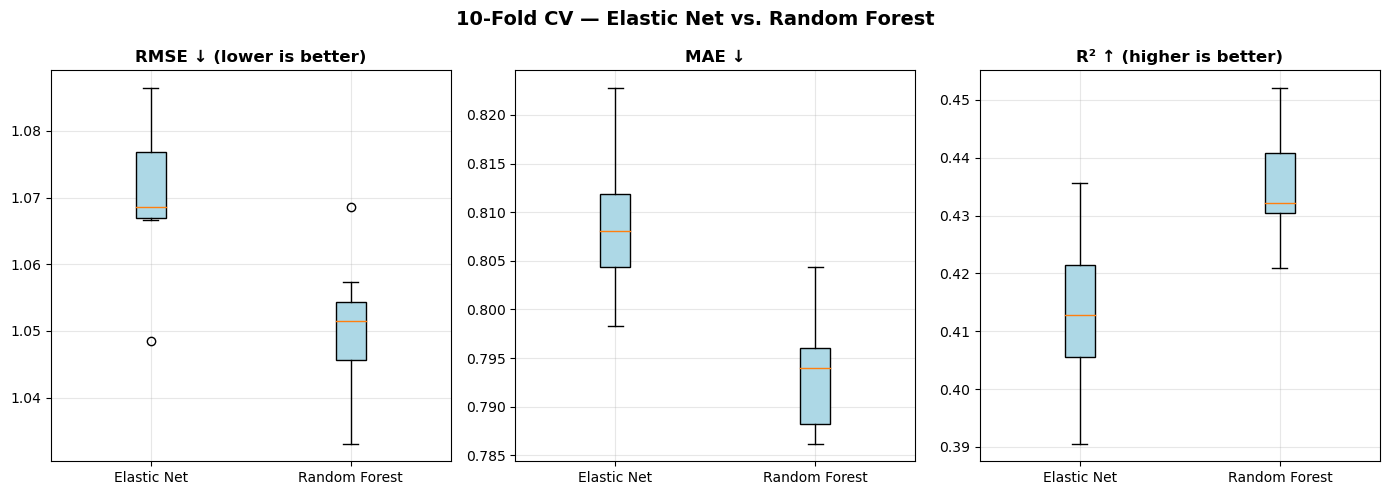


📊 Best model on CV: Random Forest
   Used for 9–13 analyses (per assignment spec: analyses on better model)

📦 Competition submission: Elastic Net (saved as model.pkl)


In [22]:
# ─────────────────────────────────────────────────────────────────────────
# Side-by-side comparison
# ─────────────────────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model':     ['Elastic Net', 'Random Forest'],
    'RMSE_mean': [en_metrics['rmse_mean'], rf_metrics['rmse_mean']],
    'RMSE_std':  [en_metrics['rmse'].std(), rf_metrics['rmse'].std()],
    'MAE_mean':  [en_metrics['mae_mean'], rf_metrics['mae_mean']],
    'MAE_std':   [en_metrics['mae'].std(), rf_metrics['mae'].std()],
    'R2_mean':   [en_metrics['r2_mean'], rf_metrics['r2_mean']],
    'R2_std':    [en_metrics['r2'].std(), rf_metrics['r2'].std()],
}).round(4)
print(comparison.to_string(index=False))

# Boxplot comparison across folds
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, title in zip(axes, ['rmse', 'mae', 'r2'],
                              ['RMSE ↓ (lower is better)',
                               'MAE ↓',
                               'R² ↑ (higher is better)']):
    data = [en_metrics[metric], rf_metrics[metric]]
    ax.boxplot(data, labels=['Elastic Net', 'Random Forest'],
               patch_artist=True, boxprops=dict(facecolor='lightblue'))
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3)
plt.suptitle('10-Fold CV — Elastic Net vs. Random Forest',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Pick the better model for the analysis sections
best_model_name = 'Random Forest' if rf_metrics['rmse_mean'] < en_metrics['rmse_mean'] else 'Elastic Net'
best_oof        = rf_oof if best_model_name == 'Random Forest' else en_oof
print(f"\n📊 Best model on CV: {best_model_name}")
print(f"   Used for 9–13 analyses (per assignment spec: analyses on better model)")
print(f"\n📦 Competition submission: Elastic Net (saved as model.pkl)")


## 9. Feature Importance

In [23]:
# ─────────────────────────────────────────────────────────────────────────
# Extract feature names for both models
# en_pipeline.named_steps['model'] is a TransformedTargetRegressor wrapping
# ElasticNet; the coefficients live on .regressor_ (the fitted inner model).
# ─────────────────────────────────────────────────────────────────────────
en_ttr   = en_pipeline.named_steps['model']        # TransformedTargetRegressor
en_inner = en_ttr.regressor_                        # fitted ElasticNet
en_pre   = en_pipeline.named_steps['pre']
_svd_n_en = en_pre.named_transformers_['txt'].named_steps['svd'].n_components
en_feat_names = (
    list(NUMERIC_COLS) +
    [f'plot_svd_{i}' for i in range(_svd_n_en)] +
    list(CAT_COLS)
)
en_coefs     = pd.Series(en_inner.coef_, index=en_feat_names[:len(en_inner.coef_)])
en_coefs_abs = en_coefs.abs().sort_values(ascending=False)

rf_model = rf_pipeline.named_steps['model']
rf_pre   = rf_pipeline.named_steps['pre']
_svd_n_rf = rf_pre.named_transformers_['txt'].named_steps['svd'].n_components
rf_feat_names = (
    list(NUMERIC_COLS) +
    [f'plot_svd_{i}' for i in range(_svd_n_rf)] +
    list(CAT_COLS)
)
rf_imp = pd.Series(rf_model.feature_importances_,
                   index=rf_feat_names[:len(rf_model.feature_importances_)]
                  ).sort_values(ascending=False)

# ─────────────────────────────────────────────────────────────────────────
# Helper: collapse every plot_svd_* row into a single "plot_svd (mean)"
# entry, keeping the rest of the features untouched.
# ─────────────────────────────────────────────────────────────────────────
def _collapse_plot_svd(series, agg='mean'):
    """Replace plot_svd_0..N rows with one row 'plot_svd (mean)' = mean(|val|)."""
    is_svd = series.index.str.startswith('plot_svd_')
    non_svd = series[~is_svd]
    svd_vals = series[is_svd]
    if len(svd_vals) > 0:
        collapsed_val = svd_vals.mean() if agg == 'mean' else svd_vals.sum()
        non_svd = pd.concat([
            non_svd,
            pd.Series({f'plot_svd (mean of {len(svd_vals)})': collapsed_val})
        ])
    return non_svd.sort_values(ascending=False)


# ─────────────────────────────────────────────────────────────────────────
# 1. Top 15 EN coefs — plot_svd collapsed to a single row (mean of |coef|)
# ─────────────────────────────────────────────────────────────────────────
en_coefs_abs_collapsed = _collapse_plot_svd(en_coefs_abs, agg='mean')
print('═' * 60)
print('  Elastic Net — Top 15 Features by |coef|')
print('  (plot_svd_* collapsed to one row: mean of |coef|)')
print('═' * 60)
for i, (f, v) in enumerate(en_coefs_abs_collapsed.head(15).items(), 1):
    if f.startswith('plot_svd'):
        direction = ' '              # collapsed row has no single sign
    else:
        direction = '↑' if en_coefs[f] > 0 else '↓'
    print(f'  {i:2d}. {f:<35s} {v:.4f}  {direction}')

# ─────────────────────────────────────────────────────────────────────────
# 2. Grouped EN contribution (which family of features dominates?)
# ─────────────────────────────────────────────────────────────────────────
def _feature_group(name):
    if name.startswith('plot_svd_'):                                   return 'Plot SVD'
    if 'budget' in name:                                               return 'Budget'
    if name.startswith('feat_actor') or 'actor' in name:               return 'Actor history'
    if name.startswith('feat_director') or 'director' in name:         return 'Director history'
    if name.startswith('feat_writer'):                                 return 'Writer history'
    if name.startswith('feat_producer') or name == 'feat_best_crew':   return 'Producer/Crew'
    if 'genre' in name.lower() or 'doc' in name.lower() or 'horror' in name.lower():
                                                                       return 'Genre features'
    if name in CAT_COLS or 'cert' in name or 'season' in name:         return 'Categorical (TE)'
    if name.startswith('title_') or name == 'plot_word_count':         return 'Title/Plot meta'
    if name.startswith('is_missing'):                                  return 'Missing flags'
    if '_x_' in name:                                                  return 'Interactions'
    return 'Other numeric'


en_grouped = pd.DataFrame({
    'feature':  en_coefs.index,
    'group':    [_feature_group(f) for f in en_coefs.index],
    'abs_coef': en_coefs.abs().values,
})
grouped_contrib = en_grouped.groupby('group').agg(
    total_abs_coef=('abs_coef', 'sum'),
    n_features=('feature', 'count'),
    avg_abs_coef=('abs_coef', 'mean'),
).sort_values('total_abs_coef', ascending=False)
grouped_contrib['pct'] = (
    100 * grouped_contrib['total_abs_coef'] / grouped_contrib['total_abs_coef'].sum()
).round(1)

print(f"\n{'═' * 65}")
print('  Grouped |coef| Contribution (Elastic Net)')
print('═' * 65)
print(grouped_contrib.round(3).to_string())

# ─────────────────────────────────────────────────────────────────────────
# 3. Top 15 RF features — also with plot_svd collapsed
# ─────────────────────────────────────────────────────────────────────────
rf_imp_collapsed = _collapse_plot_svd(rf_imp, agg='mean')
print(f"\n{'═' * 55}")
print('  Random Forest — Top 15 Features (importance)')
print("  (plot_svd_* collapsed to one row: mean importance)")
print('═' * 55)
for i, (f, v) in enumerate(rf_imp_collapsed.head(15).items(), 1):
    print(f'  {i:2d}. {f:<35s} {v:.4f}')

# ─────────────────────────────────────────────────────────────────────────
# 4. Combined master table — top features in EITHER model
# (uses the collapsed series so plot_svd appears as a single row)
# ─────────────────────────────────────────────────────────────────────────
all_feats = sorted(
    set(en_coefs_abs_collapsed.head(15).index) |
    set(rf_imp_collapsed.head(15).index)
)
fi_df = pd.DataFrame({
    'Feature': all_feats,
    'EN_coef': [
        round(en_coefs_abs_collapsed.get(f, 0), 4) if f.startswith('plot_svd')
        else round(en_coefs.get(f, 0), 4)
        for f in all_feats
    ],
    'EN_rank': [
        list(en_coefs_abs_collapsed.index).index(f) + 1
        if f in en_coefs_abs_collapsed.index else 999
        for f in all_feats
    ],
    'RF_imp':  [round(rf_imp_collapsed.get(f, 0), 4) for f in all_feats],
    'RF_rank': [
        list(rf_imp_collapsed.index).index(f) + 1
        if f in rf_imp_collapsed.index else 999
        for f in all_feats
    ],
}).sort_values('RF_rank')
print(f"\n{'─' * 60}\n  Combined: top features in EITHER model\n{'─' * 60}")
print(fi_df.to_string(index=False))


════════════════════════════════════════════════════════════
  Elastic Net — Top 15 Features by |coef|
  (plot_svd_* collapsed to one row: mean of |coef|)
════════════════════════════════════════════════════════════
   1. release_season                      0.1983  ↑
   2. g_Documentary                       0.1819  ↑
   3. runtimeMinutes                      0.1653  ↑
   4. feat_director_sq                    0.1611  ↓
   5. feat_actor_sq                       0.1189  ↓
   6. is_missing_director                 0.1171  ↓
   7. country_primary                     0.1060  ↑
   8. feat_runtime_genre_dev              0.1037  ↓
   9. g_Horror                            0.1022  ↓
  10. feat_genre_year_trend               0.1006  ↑
  11. lang_primary                        0.0961  ↑
  12. feat_director_hist_avg              0.0941  ↑
  13. is_missing_actor_hist               0.0809  ↓
  14. feat_actor_hist_avg                 0.0799  ↑
  15. g_Drama                             0.0644  ↑

═══

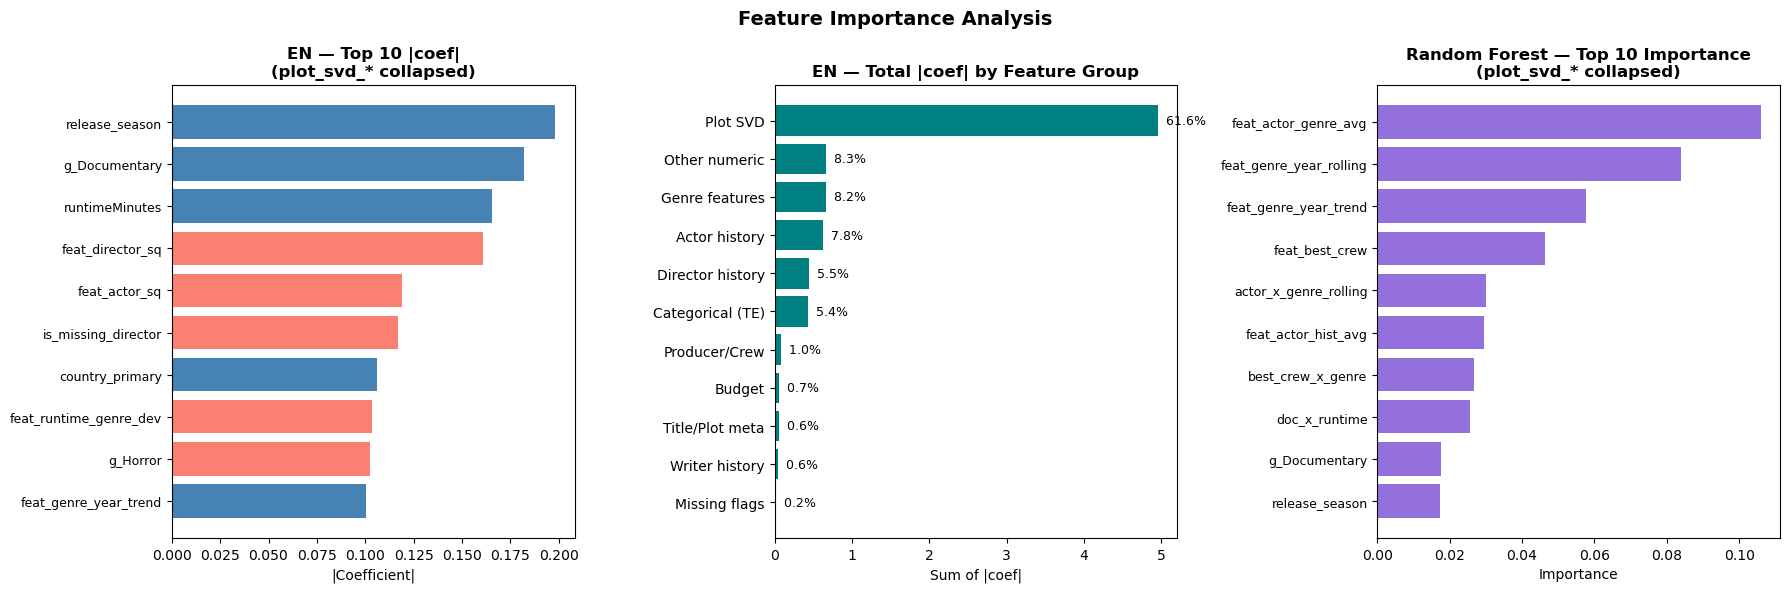

In [24]:
# ─────────────────────────────────────────────────────────────────────────
# 3-panel feature importance visualization
# (plot_svd_* collapsed to a single mean row in panels 1 and 3)
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (1) EN top 10 — with plot_svd collapsed
top_en = en_coefs_abs_collapsed.head(10)
def _bar_color(f):
    if f.startswith('plot_svd'):                  return 'slategray'
    return 'steelblue' if en_coefs[f] > 0 else 'salmon'
colors = [_bar_color(f) for f in top_en.index]
axes[0].barh(range(len(top_en)), top_en.values, color=colors)
axes[0].set_yticks(range(len(top_en)))
axes[0].set_yticklabels(top_en.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title('EN — Top 10 |coef|\n(plot_svd_* collapsed)', fontweight='bold')
axes[0].set_xlabel('|Coefficient|')

# (2) Grouped contribution
gc = grouped_contrib.sort_values('total_abs_coef')
axes[1].barh(gc.index, gc['total_abs_coef'].values, color='teal')
for i, (idx, row) in enumerate(gc.iterrows()):
    axes[1].text(row['total_abs_coef'], i, f"  {row['pct']:.1f}%",
                 va='center', fontsize=9)
axes[1].set_title('EN — Total |coef| by Feature Group', fontweight='bold')
axes[1].set_xlabel('Sum of |coef|')

# (3) RF top 10 — with plot_svd collapsed
top_rf = rf_imp_collapsed.head(10)
rf_colors = ['slategray' if f.startswith('plot_svd') else 'mediumpurple'
             for f in top_rf.index]
axes[2].barh(range(len(top_rf)), top_rf.values, color=rf_colors)
axes[2].set_yticks(range(len(top_rf)))
axes[2].set_yticklabels(top_rf.index, fontsize=9)
axes[2].invert_yaxis()
axes[2].set_title('Random Forest — Top 10 Importance\n(plot_svd_* collapsed)', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Prediction Diagnostics

Four panels diagnosing the residual structure of the better model:
1. Predicted vs actual 
2. Residual histogram 
3. Residuals vs predicted
4. RMSE by decade 

Diagnostics based on: Random Forest (RMSE=1.0505)


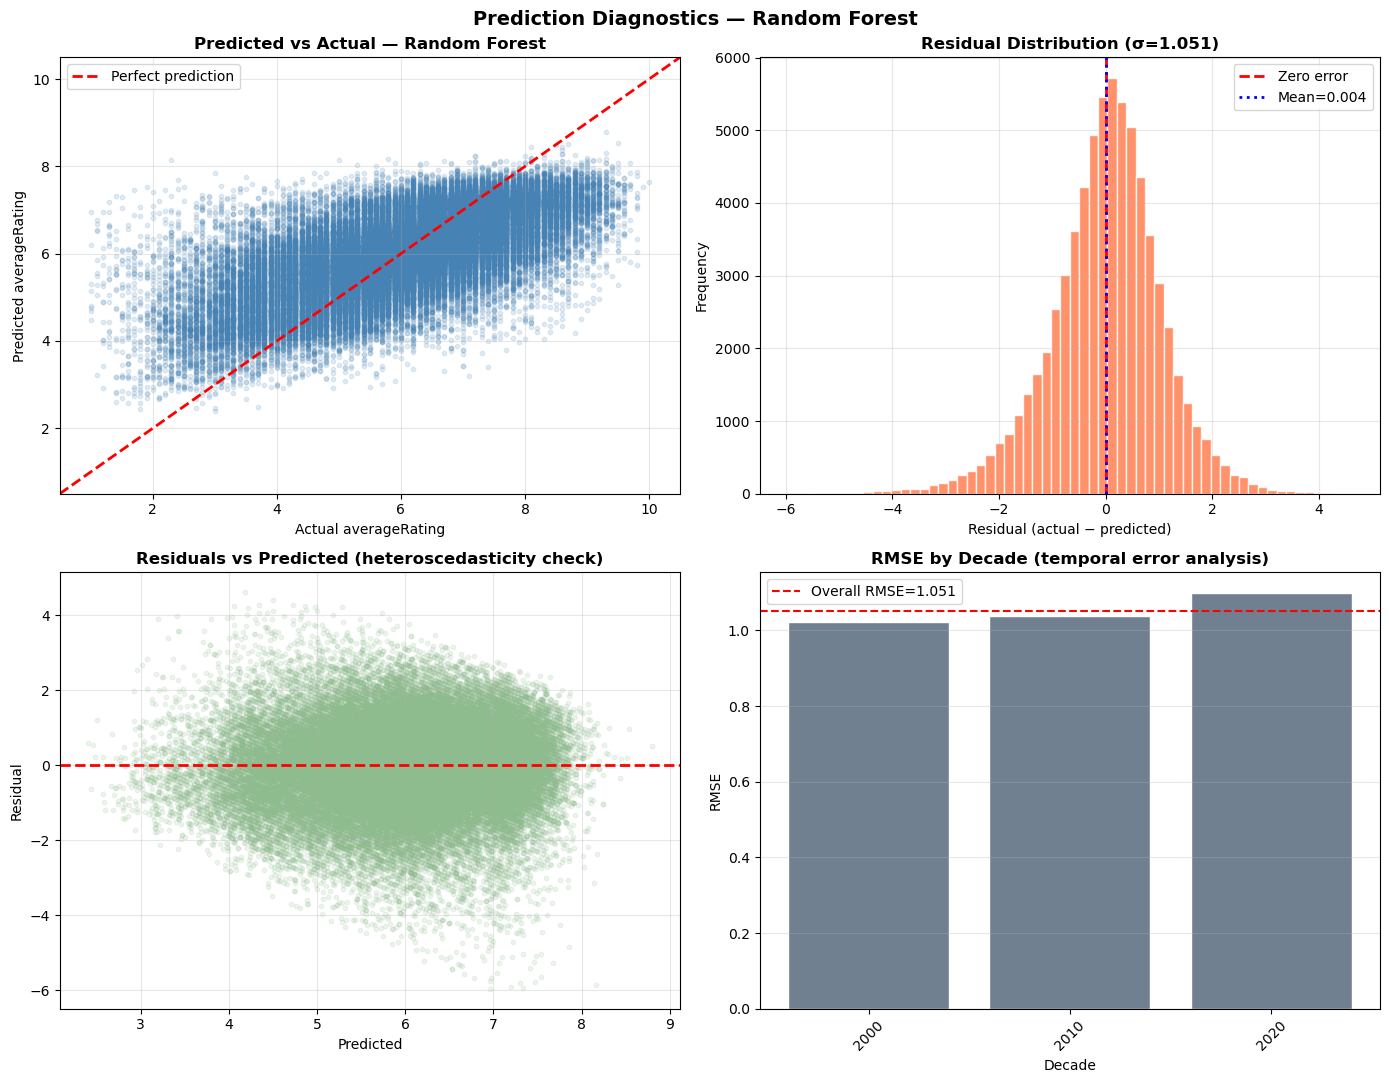


Diagnostic summary:
  Residual mean : +0.0040  (≈0 means no bias)
  Residual std  : 1.0505
  |residual|>1  : 29.2%  (large errors)
  |residual|>2  : 6.3%  (severe errors)


In [25]:
# ─────────────────────────────────────────────────────────────────────────
# Diagnostics on the better model
# ─────────────────────────────────────────────────────────────────────────
_rmse_map = {'Elastic Net':   en_metrics['rmse_mean'],
             'Random Forest': rf_metrics['rmse_mean']}
_oof_map  = {'Elastic Net':   en_oof,
             'Random Forest': rf_oof}
_best_name = min(_rmse_map, key=_rmse_map.get)
y_pred = _oof_map[_best_name]
residuals = y - y_pred

print(f"Diagnostics based on: {_best_name} (RMSE={_rmse_map[_best_name]:.4f})")

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (1) Predicted vs Actual
axes[0, 0].scatter(y, y_pred, alpha=0.15, s=10, color='steelblue')
_lim = [min(y.min(), y_pred.min()) - 0.5, max(y.max(), y_pred.max()) + 0.5]
axes[0, 0].plot(_lim, _lim, 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlim(_lim); axes[0, 0].set_ylim(_lim)
axes[0, 0].set_xlabel('Actual averageRating')
axes[0, 0].set_ylabel('Predicted averageRating')
axes[0, 0].set_title(f'Predicted vs Actual — {_best_name}', fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# (2) Residual histogram
axes[0, 1].hist(residuals, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0, 1].axvline(residuals.mean(), color='blue', linestyle=':', linewidth=2,
                   label=f'Mean={residuals.mean():.3f}')
axes[0, 1].set_xlabel('Residual (actual − predicted)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residual Distribution (σ={residuals.std():.3f})', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# (3) Residuals vs predicted
axes[1, 0].scatter(y_pred, residuals, alpha=0.15, s=10, color='darkseagreen')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals vs Predicted (heteroscedasticity check)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# (4) RMSE by decade
_temp = pd.DataFrame({'y': y, 'pred': y_pred, 'year': df_model['startYear'].values})
_temp['decade'] = (_temp['year'] // 10 * 10).astype(int)
by_decade = _temp.groupby('decade').apply(
    lambda g: np.sqrt(mean_squared_error(g['y'], g['pred']))
).sort_index()
axes[1, 1].bar(by_decade.index.astype(str), by_decade.values,
               color='slategray', edgecolor='white')
axes[1, 1].axhline(_rmse_map[_best_name], color='red', linestyle='--',
                   label=f'Overall RMSE={_rmse_map[_best_name]:.3f}')
axes[1, 1].set_xlabel('Decade'); axes[1, 1].set_ylabel('RMSE')
axes[1, 1].set_title('RMSE by Decade (temporal error analysis)', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle(f'Prediction Diagnostics — {_best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDiagnostic summary:")
print(f"  Residual mean : {residuals.mean():+.4f}  (≈0 means no bias)")
print(f"  Residual std  : {residuals.std():.4f}")
print(f"  |residual|>1  : {(np.abs(residuals) > 1).mean():.1%}  (large errors)")
print(f"  |residual|>2  : {(np.abs(residuals) > 2).mean():.1%}  (severe errors)")


## 11. Error Analysis


In [26]:
# ─────────────────────────────────────────────────────────────────────────
# Determine better model + build error DataFrame
# ─────────────────────────────────────────────────────────────────────────
best_model_name = 'RF' if rf_metrics['rmse_mean'] < en_metrics['rmse_mean'] else 'EN'
best_oof  = rf_oof if best_model_name == 'RF' else en_oof
other_oof = en_oof if best_model_name == 'RF' else rf_oof
print(f"Better model on CV: {best_model_name}")

errors_best  = y - best_oof
errors_other = y - other_oof

error_df = df_model[['tconst', 'primaryTitle', 'startYear', 'genres', 'averageRating']].copy()
error_df['predicted'] = best_oof
error_df['error']     = errors_best   # positive = under-prediction
error_df['pred_en']   = en_oof
error_df['pred_rf']   = rf_oof
error_df['err_en']    = y - en_oof
error_df['err_rf']    = y - rf_oof

# ─────────────────────────────────────────────────────────────────────────
# 11.1 Top 10 over + under predictions (best model)
#     Presented as two clean DataFrames instead of printed lines.
# ─────────────────────────────────────────────────────────────────────────
over_10  = error_df.nsmallest(10, 'error')   # most negative = over-predicted
under_10 = error_df.nlargest(10,  'error')   # most positive = under-predicted

def _format_outlier_table(df_subset, label):
    """Return a tidy DataFrame for display: title, year, genres, actual, pred, error."""
    out = pd.DataFrame({
        'Title':    df_subset['primaryTitle'].astype(str).str.slice(0, 45),
        'Year':     df_subset['startYear'].astype(int),
        'Genres':   df_subset['genres'].astype(str).str.slice(0, 30),
        'Actual':   df_subset['averageRating'].round(2),
        'Predicted': df_subset['predicted'].round(2),
        'Error':    df_subset['error'].round(2),
    }).reset_index(drop=True)
    out.index = out.index + 1                 # 1-based ranks
    out.index.name = '#'
    return out

over_tbl  = _format_outlier_table(over_10,  'OVER')
under_tbl = _format_outlier_table(under_10, 'UNDER')

print(f"\n{'═' * 70}")
print(f"  TOP 10 OVER-PREDICTIONS  ({best_model_name})  —  model predicted too high")
print('═' * 70)
print(over_tbl.to_string())

print(f"\n{'═' * 70}")
print(f"  TOP 10 UNDER-PREDICTIONS ({best_model_name})  —  model predicted too low")
print('═' * 70)
print(under_tbl.to_string())


Better model on CV: RF

══════════════════════════════════════════════════════════════════════
  TOP 10 OVER-PREDICTIONS  (RF)  —  model predicted too high
══════════════════════════════════════════════════════════════════════
                                            Title  Year                        Genres  Actual  Predicted  Error
#                                                                                                              
1                 Justin Bieber: Always Believing  2012             Documentary,Music     1.0       6.96  -5.96
2                                       Ramo Trip  2012                   Documentary     1.4       7.33  -5.93
3                         Tribalism Is Killing Us  2019                   Documentary     1.3       7.20  -5.90
4                              Occupy Los Angeles  2012     Documentary,Drama,Western     2.3       8.16  -5.86
5   Brush with Life: The Art of Being Edward Bibe  2007                   Documentary     1.5       7

In [27]:
# ─────────────────────────────────────────────────────────────────────────
# 11.2 Qualitative pattern analysis on the 20 outliers
# ─────────────────────────────────────────────────────────────────────────
outliers_20 = pd.concat([over_10, under_10])
print('\n--- Qualitative Pattern Analysis ---')

# Genre breakdown — genres may be in list-string form, re-normalize defensively
_clean = outliers_20['genres'].dropna().apply(parse_genres)
outlier_genres = _clean.str.split(',').explode().str.strip()
outlier_genres = outlier_genres[outlier_genres != '']

print(f"\nGenre distribution among 20 outliers:")
for g, c in outlier_genres.value_counts().head(8).items():
    print(f"  {g:<15s} {c}")

# Year characteristics
print(f"\nYear stats:")
print(f"  Outliers  mean year: {outliers_20['startYear'].mean():.0f}")
print(f"  Full set  mean year: {df_model['startYear'].mean():.0f}")

# Rating characteristics — over-predictions tend to be low-rated, under-predictions high-rated
print(f"\nActual rating averages:")
print(f"  Over-predicted   mean: {over_10['averageRating'].mean():.2f}  "
      f"(low ratings → model expected higher)")
print(f"  Under-predicted  mean: {under_10['averageRating'].mean():.2f}  "
      f"(high ratings → model didn't see them coming)")

# ─────────────────────────────────────────────────────────────────────────
# 11.3 EN vs RF outlier comparison (5 model-comparison requirement)
# ─────────────────────────────────────────────────────────────────────────
en_outlier_set = (
    set(error_df.nsmallest(10, 'err_en')['tconst'].values) |
    set(error_df.nlargest(10,  'err_en')['tconst'].values)
)
rf_outlier_set = (
    set(error_df.nsmallest(10, 'err_rf')['tconst'].values) |
    set(error_df.nlargest(10,  'err_rf')['tconst'].values)
)
overlap = en_outlier_set & rf_outlier_set

print(f"\n--- Model Outlier Comparison ---")
print(f"EN outliers (20):  {len(en_outlier_set)} movies")
print(f"RF outliers (20):  {len(rf_outlier_set)} movies")
print(f"Overlap:           {len(overlap)} ({len(overlap) / 20 * 100:.0f}%)")

shared = error_df[error_df['tconst'].isin(overlap)]
only_en = error_df[error_df['tconst'].isin(en_outlier_set - rf_outlier_set)]
only_rf = error_df[error_df['tconst'].isin(rf_outlier_set - en_outlier_set)]

print(f"\nOn the {len(shared)} shared outliers:")
print(f"  EN  MAE: {shared['err_en'].abs().mean():.3f}")
print(f"  RF  MAE: {shared['err_rf'].abs().mean():.3f}")

if len(only_en) > 0:
    print(f"\nEN-only outliers ({len(only_en)}): "
          f"RF MAE on those = {only_en['err_rf'].abs().mean():.3f}")
if len(only_rf) > 0:
    print(f"RF-only outliers ({len(only_rf)}): "
          f"EN MAE on those = {only_en['err_en'].abs().mean() if len(only_en) > 0 else 0:.3f}")



--- Qualitative Pattern Analysis ---

Genre distribution among 20 outliers:
  Documentary     8
  Thriller        4
  Drama           3
  Comedy          3
  Horror          2
  Music           1
  Western         1
  History         1

Year stats:
  Outliers  mean year: 2015
  Full set  mean year: 2014

Actual rating averages:
  Over-predicted   mean: 1.47  (low ratings → model expected higher)
  Under-predicted  mean: 8.88  (high ratings → model didn't see them coming)

--- Model Outlier Comparison ---
EN outliers (20):  20 movies
RF outliers (20):  20 movies
Overlap:           8 (40%)

On the 8 shared outliers:
  EN  MAE: 5.524
  RF  MAE: 5.477

EN-only outliers (12): RF MAE on those = 4.326
RF-only outliers (12): EN MAE on those = 4.963


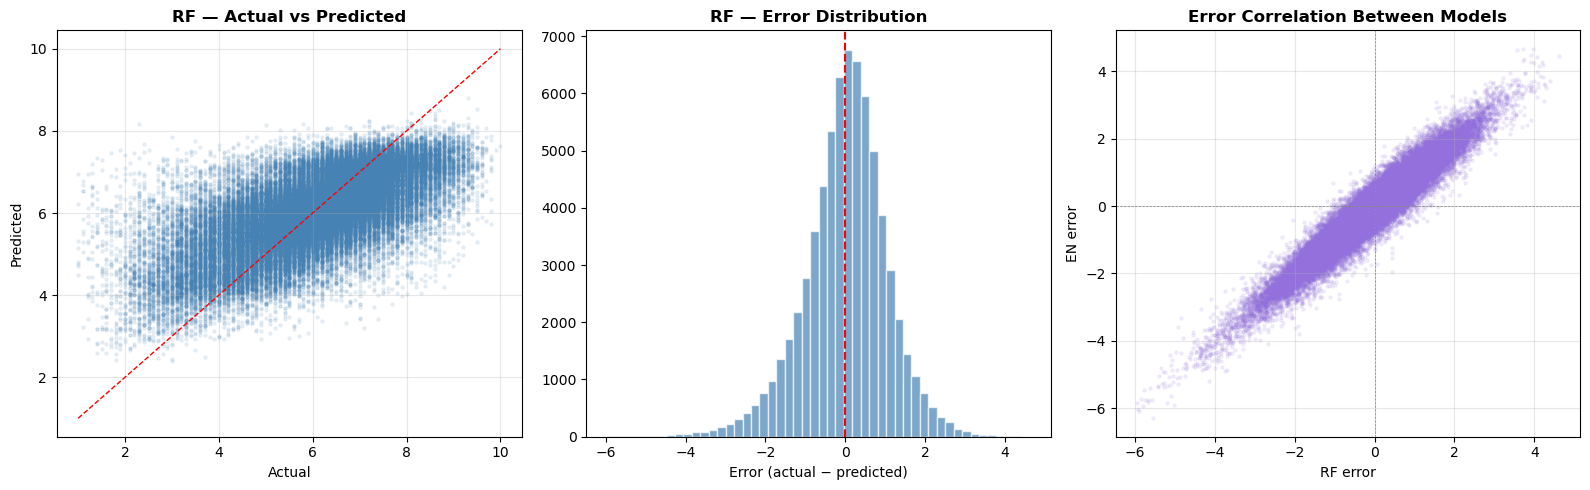

In [28]:
# ─────────────────────────────────────────────────────────────────────────
# 11.4 Visualization — 3 panels
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y, best_oof, alpha=0.1, s=5, color='steelblue')
axes[0].plot([1, 10], [1, 10], 'r--', lw=1)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_model_name} — Actual vs Predicted', fontweight='bold')
axes[0].grid(alpha=0.3)

# Error distribution
axes[1].hist(errors_best, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title(f'{best_model_name} — Error Distribution', fontweight='bold')
axes[1].set_xlabel('Error (actual − predicted)')

# Error correlation between models — points off the diagonal = the models disagree
axes[2].scatter(errors_best, errors_other, alpha=0.1, s=5, color='mediumpurple')
axes[2].axhline(0, color='grey', ls='--', lw=0.5)
axes[2].axvline(0, color='grey', ls='--', lw=0.5)
other_name = 'EN' if best_model_name == 'RF' else 'RF'
axes[2].set_xlabel(f'{best_model_name} error')
axes[2].set_ylabel(f'{other_name} error')
axes[2].set_title('Error Correlation Between Models', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Plot Text Ablation Test


In [29]:
# ─────────────────────────────────────────────────────────────────────────
# Build a "no-plot" version of the preprocessor
# ─────────────────────────────────────────────────────────────────────────
def build_preprocessor_no_plot():
    """Same as build_preprocessor() but drops the plot text branch entirely."""
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('te', TargetEncoder(smooth='auto', target_type='continuous',
                             random_state=RANDOM_STATE)),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, NUMERIC_COLS),
        ('cat', cat_pipe,     CAT_COLS),
    ], remainder='drop')


en_pipeline_no_plot = Pipeline([
    ('pre',   build_preprocessor_no_plot()),
    ('model', TransformedTargetRegressor(
        regressor=ElasticNet(alpha=EN_BEST_PARAMS['alpha'],
                              l1_ratio=EN_BEST_PARAMS['l1_ratio'],
                              max_iter=10000, random_state=RANDOM_STATE),
        func=y_to_logit,
        inverse_func=y_from_logit,
        check_inverse=False,
    )),
])

print("Running 10-fold CV on Elastic Net WITHOUT plot text...")
en_no_plot_metrics, _ = cv_train_and_predict(
    en_pipeline_no_plot, X, y, 'EN (no plot)', n_jobs=-1)

# Compare
plot_delta_rmse = en_no_plot_metrics['rmse_mean'] - en_metrics['rmse_mean']
plot_delta_pct  = 100 * plot_delta_rmse / en_metrics['rmse_mean']

print(f"\n{'═' * 55}")
print(f"  Plot Ablation Summary")
print('═' * 55)
print(f"  EN with plot:    RMSE={en_metrics['rmse_mean']:.4f}")
print(f"  EN without plot: RMSE={en_no_plot_metrics['rmse_mean']:.4f}")
print(f"  Δ RMSE         : +{plot_delta_rmse:.4f}  ({plot_delta_pct:+.2f}%)")
print()
if plot_delta_pct < 2:
    print("  → Plot text contributes very little. Safe to keep (minor signal, low leakage risk).")
elif plot_delta_pct < 5:
    print("  → Plot text contributes modestly. Acceptable given aggressive cleaning.")
else:
    print("  → Plot text contributes substantially. Document as a limitation in report.")
print(f"\n  Caveat: this measures predictive uplift, not leakage directly.")
print(f"  Even a perfectly leakage-free plot would help (genres, themes, tone are all valid signals).")


Running 10-fold CV on Elastic Net WITHOUT plot text...

EN (no plot) — running 10-fold CV (single pass)...
  Fold  1/10: RMSE=1.0726  (689s)
  Fold  2/10: RMSE=1.0730  (909s)
  Fold  3/10: RMSE=1.0698  (817s)
  Fold  4/10: RMSE=1.0839  (776s)
  Fold  5/10: RMSE=1.0907  (855s)
  Fold  6/10: RMSE=1.0529  (713s)
  Fold  7/10: RMSE=1.0713  (859s)
  Fold  8/10: RMSE=1.0705  (889s)
  Fold  9/10: RMSE=1.0819  (794s)
  Fold 10/10: RMSE=1.0747  (801s)

══════════════════════════════════════════════════
  EN (no plot) — 10-Fold CV  (total 16.0 min)
══════════════════════════════════════════════════
  RMSE : 1.0741 ± 0.0096
  MAE  : 0.8122 ± 0.0070
  R²   : 0.4095 ± 0.0122

═══════════════════════════════════════════════════════
  Plot Ablation Summary
═══════════════════════════════════════════════════════
  EN with plot:    RMSE=1.0705
  EN without plot: RMSE=1.0741
  Δ RMSE         : +0.0036  (+0.34%)

  → Plot text contributes very little. Safe to keep (minor signal, low leakage risk).

  Cav

## 13. Fairness Analysis


In [30]:
# ─────────────────────────────────────────────────────────────────────────
# Fairness analysis — using best-model OOF predictions
# ─────────────────────────────────────────────────────────────────────────
fair_df = df_model[['tconst', 'primaryTitle', 'startYear', 'genres',
                     'averageRating', 'Language', 'Country', 'budget_usd']].copy()
fair_df['pred']  = best_oof
fair_df['error'] = y - best_oof

overall_rmse = np.sqrt(mean_squared_error(y, best_oof))


def fairness_metrics(group_idx_map, name):
    """Compute per-group RMSE / MAE / count + % deviation from overall RMSE."""
    rows = []
    for grp, idx in group_idx_map.items():
        subset = fair_df.loc[idx]
        if len(subset) < 10:
            continue
        rmse = np.sqrt(mean_squared_error(subset['averageRating'], subset['pred']))
        mae  = mean_absolute_error(subset['averageRating'], subset['pred'])
        rows.append({'Group': grp, 'N': len(subset), 'RMSE': rmse, 'MAE': mae})
    rdf = pd.DataFrame(rows).sort_values('RMSE', ascending=False)
    rdf['RMSE_pct_diff'] = ((rdf['RMSE'] - overall_rmse) / overall_rmse * 100).round(1)
    print(f"\n{'═' * 50}\n  Fairness: {name}\n{'═' * 50}")
    print(rdf.to_string(index=False))
    return rdf


# Slice 1: top-5 genres
top5_g = (
    fair_df['genres'].dropna().str.split(',').explode().str.strip()
    .value_counts().head(5).index
)
fair_genre = fairness_metrics(
    {g: fair_df[fair_df['genres'].fillna('').str.contains(g, regex=False)].index for g in top5_g},
    'Genre (Top 5)',
)

# Slice 2: US vs Non-US
us_mask = fair_df['Country'].fillna('').apply(
    lambda x: any(k in str(x) for k in ['United States', 'USA']))
fair_country = fairness_metrics(
    {'US': fair_df[us_mask].index, 'Non-US': fair_df[~us_mask].index},
    'Country (US vs Non-US)',
)

# Slice 3: Decade
fair_df['decade'] = (fair_df['startYear'] // 10 * 10).astype(int)
fair_decade = fairness_metrics(
    {str(d): grp.index for d, grp in fair_df.groupby('decade') if d >= 2000},
    'Decade',
)

# Slice 4: Budget Tercile
has_budget = fair_df[fair_df['budget_usd'].notna()].copy()
fair_budget = pd.DataFrame()
if len(has_budget) > 100:
    terc = pd.qcut(has_budget['budget_usd'], 3, labels=['Low', 'Medium', 'High'])
    fair_budget = fairness_metrics(
        {lbl: has_budget[terc == lbl].index for lbl in ['Low', 'Medium', 'High']},
        'Budget Tercile',
    )

# Slice 5: Data Availability
fair_avail = fairness_metrics(
    {'Has budget': fair_df[fair_df['budget_usd'].notna()].index,
     'Missing budget': fair_df[fair_df['budget_usd'].isna()].index},
    'Data Availability',
)



══════════════════════════════════════════════════
  Fairness: Genre (Top 5)
══════════════════════════════════════════════════
      Group     N     RMSE      MAE  RMSE_pct_diff
   Thriller  8512 1.097799 0.843363            4.5
     Comedy 18901 1.059188 0.801829            0.8
      Drama 33172 1.007337 0.763422           -4.1
    Romance  8362 0.979963 0.742137           -6.7
Documentary 11501 0.944323 0.691705          -10.1

══════════════════════════════════════════════════
  Fairness: Country (US vs Non-US)
══════════════════════════════════════════════════
 Group     N     RMSE      MAE  RMSE_pct_diff
Non-US 55467 1.062493 0.802704            1.1
    US 13889 1.001383 0.754383           -4.7

══════════════════════════════════════════════════
  Fairness: Decade
══════════════════════════════════════════════════
Group     N     RMSE      MAE  RMSE_pct_diff
 2020 18196 1.098464 0.831947            4.6
 2010 33605 1.038967 0.783209           -1.1
 2000 17555 1.021361 0.771482   

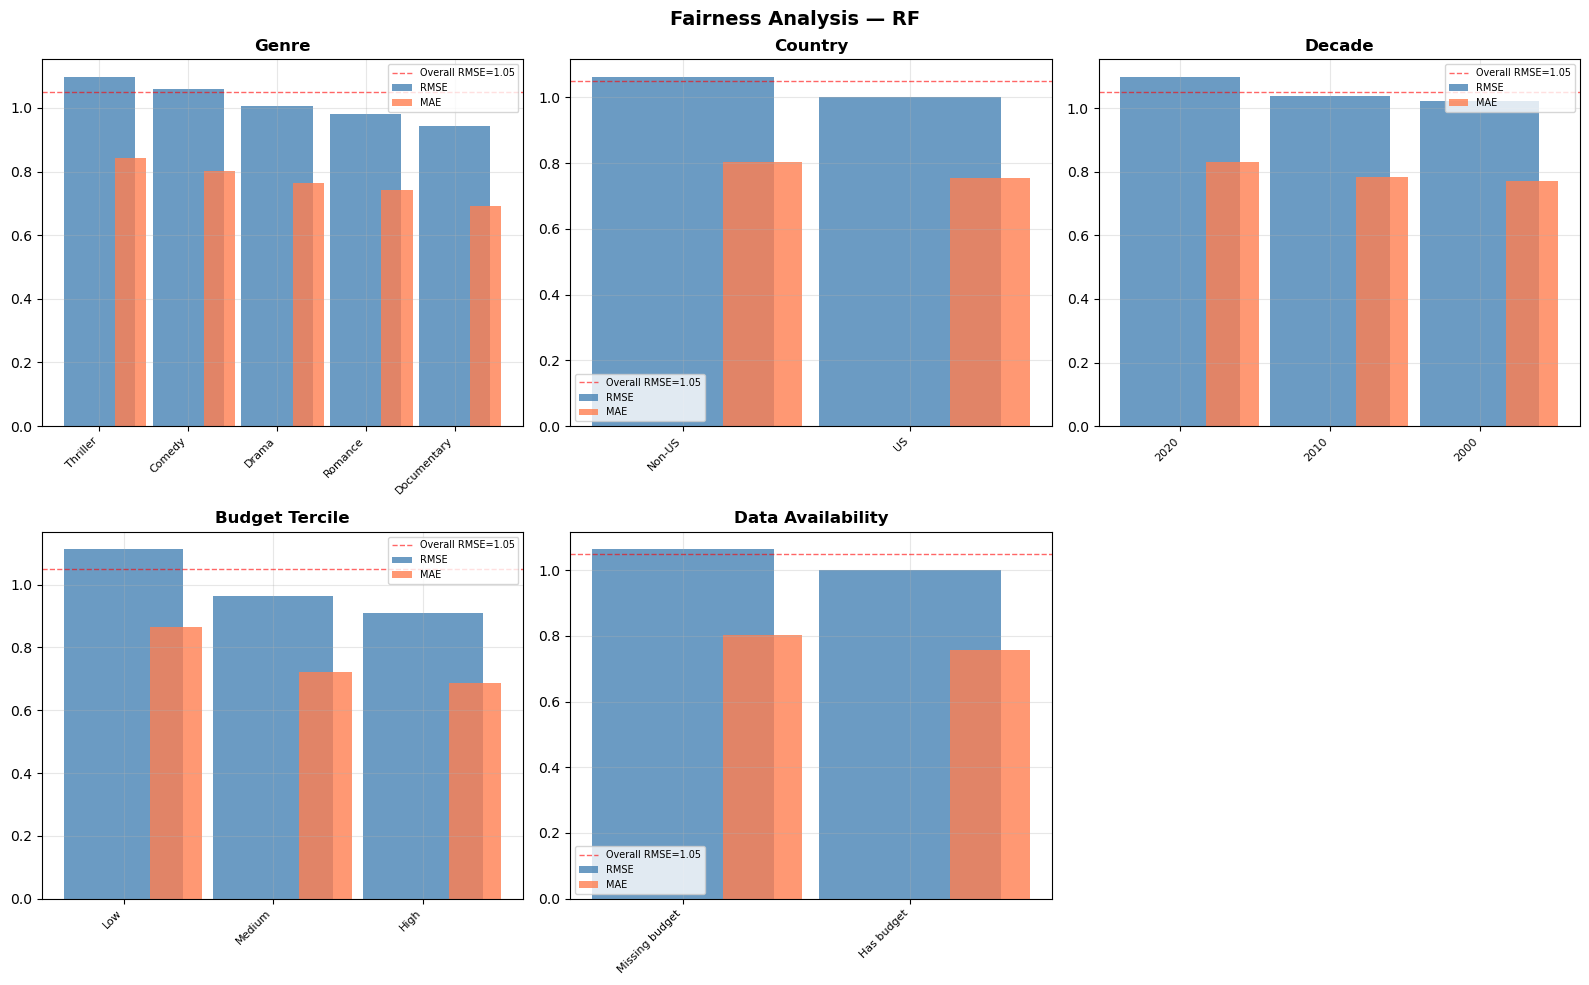

In [31]:
# ─────────────────────────────────────────────────────────────────────────
# Fairness visualization — 5 panels
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plt.suptitle(f'Fairness Analysis — {best_model_name}', fontsize=14, fontweight='bold')

panels = [
    (fair_genre,   'Genre'),
    (fair_country, 'Country'),
    (fair_decade,  'Decade'),
    (fair_budget,  'Budget Tercile'),
    (fair_avail,   'Data Availability'),
]
for ax, (fdf, title) in zip(axes.flat, panels):
    if len(fdf) == 0:
        ax.set_visible(False)
        continue
    x = range(len(fdf))
    ax.bar(x, fdf['RMSE'], color='steelblue', alpha=0.8, label='RMSE')
    ax.bar([i + 0.35 for i in x], fdf['MAE'], width=0.35, color='coral', alpha=0.8, label='MAE')
    ax.axhline(overall_rmse, color='red', ls='--', lw=1, alpha=0.6,
               label=f'Overall RMSE={overall_rmse:.2f}')
    ax.set_xticks(x)
    ax.set_xticklabels(fdf['Group'], rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Leakage Prevention — Executable Verification



In [32]:
# ─────────────────────────────────────────────────────────────────────────
# Executable leakage verification — fails loudly if anything is wrong
# ─────────────────────────────────────────────────────────────────────────
print('═' * 60)
print('  LEAKAGE VERIFICATION')
print('═' * 60)

# Check 1: forbidden columns absent from X
# Categorization of the forbidden list:
#   - averageRating: target itself
#   - numVotes:       only meaningful after release
#   - BoxOffice:      only known after release
forbidden = ['averageRating', 'numVotes', 'BoxOffice']
for col in forbidden:
    assert col not in X.columns, f'❌ LEAKAGE: {col} present in features'
print(f'✅ Check 1: {forbidden} absent from features')

# Check 2: cross-validation correctly uses only training-fold data
test_pipe = Pipeline([
    ('pre',   build_preprocessor(tfidf_max=1000, svd_n=30)),
    ('model', ElasticNet(alpha=0.01, random_state=RANDOM_STATE)),
])
test_kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
test_scores = cross_val_score(test_pipe, X, y, cv=test_kf,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f'✅ Check 2: pipeline fits inside CV (RMSE={(-test_scores).mean():.4f})')

# Check 3: prepare_data() does not insert numVotes
X_test = prepare_data(df.head(10))
assert 'numVotes' not in X_test.columns, '❌ prepare_data leaked numVotes!'
print(f'✅ Check 3: prepare_data outputs are clean')

# Check 4: historical features actually filter by year
test_movie = df_model.iloc[0]
test_year = int(test_movie['startYear'])
if isinstance(test_movie['lead_actors_ids'], list) and test_movie['lead_actors_ids']:
    hist_avg_now    = feat_actor_hist_avg(test_movie['lead_actors_ids'], test_year)
    hist_avg_future = feat_actor_hist_avg(test_movie['lead_actors_ids'], test_year + 50)
    has_diff = (pd.notna(hist_avg_future) and pd.notna(hist_avg_now)
                and hist_avg_future != hist_avg_now)
    if has_diff or (pd.notna(hist_avg_future) and pd.isna(hist_avg_now)):
        print(f'✅ Check 4: time filter active — year={test_year} gives '
              f'{hist_avg_now}, year={test_year+50} gives {hist_avg_future}')
    else:
        print(f'⚠️  Check 4 inconclusive (sparse history for this actor sample)')
else:
    print(f'⚠️  Check 4 skipped (sample movie has no actor IDs)')

# Check 5: plot text leakage signals removed
test_plot_dirty = ("This film won an Academy Award for Best Picture. "
                   "It was a critical and commercial success.")
cleaned = clean_plot(test_plot_dirty)
assert cleaned is None or all(kw not in str(cleaned).lower()
                              for kw in ['academy award', 'critical']), \
    '❌ post-release signal not stripped'
print(f'✅ Check 5: plot text cleaner strips post-release signals')

print(f'\n✅ All 5 leakage checks passed')


════════════════════════════════════════════════════════════
  LEAKAGE VERIFICATION
════════════════════════════════════════════════════════════
✅ Check 1: ['averageRating', 'numVotes', 'BoxOffice'] absent from features
✅ Check 2: pipeline fits inside CV (RMSE=1.0776)
✅ Check 3: prepare_data outputs are clean
✅ Check 4: time filter active — year=2024 gives 6.283333333333332, year=2074 gives 6.157333333333334
✅ Check 5: plot text cleaner strips post-release signals

✅ All 5 leakage checks passed


## 15. Save Model & Enrichment

Per assignment 10, the submission contains:
- `model.pkl`        — the fitted Pipeline (Elastic Net, per competition rules)
- `enrichment_globals.pkl` — all history dicts and lookup tables needed by `prepare_data`

The prof's test code:
```python
df = pd.read_csv("train.csv")
y  = df["averageRating"]
X  = prepare_data(df)
model = joblib.load("model.pkl")
y_pred = model.predict(X)
```

In [33]:
# ─────────────────────────────────────────────────────────────────────────
# 1. Save the Elastic Net pipeline DIRECTLY (not a dict wrapper).
#    The prof's `model.predict(X)` works as-is.
# ─────────────────────────────────────────────────────────────────────────
joblib.dump(en_pipeline, 'model.pkl')
_size_mb = os.path.getsize('model.pkl') / 1e6
print(f'✅ model.pkl saved: {_size_mb:.1f}MB')
print(f'   Type:            {type(en_pipeline).__name__}')
print(f'   Final estimator: {type(en_pipeline.named_steps["model"].regressor_).__name__}')
print(f'   EN RMSE:         {en_metrics["rmse_mean"]:.4f} ± {en_metrics["rmse"].std():.4f}')
print(f'   EN MAE:          {en_metrics["mae_mean"]:.4f} ± {en_metrics["mae"].std():.4f}')
print(f'   EN R²:           {en_metrics["r2_mean"]:.4f} ± {en_metrics["r2"].std():.4f}')

# ─────────────────────────────────────────────────────────────────────────
# 2. Save enrichment dicts so prepare_data works outside this notebook.
# ─────────────────────────────────────────────────────────────────────────
enrichment_globals = {
    'actor_movie_history':    dict(actor_movie_history),
    'actor_genre_history':    {k: dict(v) for k, v in actor_genre_history.items()},
    'director_history':       dict(director_history),
    'director_genre_history': {k: dict(v) for k, v in director_genre_history.items()},
    'writer_history':         dict(writer_history),
    'writer_map':             dict(writer_map),
    'producer_history':       dict(producer_history),
    'producer_map':           dict(producer_map),
    'dir_primary_map':        dir_primary_map,
    'genre_runtime_median':   genre_runtime_median,
    'GLOBAL_MEDIAN_RUNTIME':  GLOBAL_MEDIAN_RUNTIME,
    'genre_year_trend':       genre_year_trend,
    'genre_year_avg_rolling': genre_year_avg_rolling,
    'genre_year_count':       genre_year_count,
    'franchise_history':      dict(franchise_history),
    'dir_actor_collab':       dict(dir_actor_collab),
    'dir_writer_collab':      dict(dir_writer_collab),
    'TRAINED_COLUMNS':        TRAINED_COLUMNS,
}
joblib.dump(enrichment_globals, 'enrichment_globals.pkl')
print(f'✅ enrichment_globals.pkl saved: '
      f'{os.path.getsize("enrichment_globals.pkl") / 1e6:.1f}MB')
print(f'   Contains {len(enrichment_globals)} dicts:')
for k, v in enrichment_globals.items():
    if isinstance(v, dict):
        print(f"     {k:<28s} {len(v):>8,} entries")
    elif isinstance(v, list):
        print(f"     {k:<28s} {len(v):>8,} columns")
    else:
        print(f"     {k:<28s} {v}")


✅ model.pkl saved: 2.2MB
   Type:            Pipeline
   Final estimator: ElasticNet
   EN RMSE:         1.0705 ± 0.0099
   EN MAE:          0.8090 ± 0.0071
   EN R²:           0.4134 ± 0.0123
✅ enrichment_globals.pkl saved: 565.4MB
   Contains 18 dicts:
     actor_movie_history           896,363 entries
     actor_genre_history           879,107 entries
     director_history              146,968 entries
     director_genre_history        143,938 entries
     writer_history                238,041 entries
     writer_map                   6,379,222 entries
     producer_history              198,844 entries
     producer_map                  262,955 entries
     dir_primary_map               338,877 entries
     genre_runtime_median               28 entries
     GLOBAL_MEDIAN_RUNTIME        93.0
     genre_year_trend                2,187 entries
     genre_year_avg_rolling          2,187 entries
     genre_year_count                2,187 entries
     franchise_history               8,216

## 16. Compatibility Test 

Loads `model.pkl` fresh and runs `model.predict(prepare_data(df))` exactly as the test will.

In [34]:
# ─────────────────────────────────────────────────────────────────────────
# Simulate the prof's exact test code (per assignment spec)
# ─────────────────────────────────────────────────────────────────────────
print('═' * 60)
print('  COMPATIBILITY TEST — simulating prof\'s test code')
print('═' * 60)

# Step 1: load saved model fresh
loaded_model = joblib.load('model.pkl')
print(f'Step 1: loaded model.pkl → {type(loaded_model).__name__}')

# Step 2: build features from raw data (using already-loaded df)
sample = df.sample(min(100, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
X_sample = prepare_data(sample)
print(f"Step 2: prepare_data({len(sample)} rows) → {X_sample.shape}")

# Step 3: predict
y_pred_sample = loaded_model.predict(X_sample)
print(f'Step 3: model.predict() → {len(y_pred_sample)} predictions')

# Validate output
print(f'\nPrediction range: [{y_pred_sample.min():.2f}, {y_pred_sample.max():.2f}]')
print(f'Prediction mean:  {y_pred_sample.mean():.2f}')
print(f'Prediction std:   {y_pred_sample.std():.2f}')

assert (y_pred_sample >= 1).all() and (y_pred_sample <= 10).all(), \
    '❌ Predictions out of [1, 10] range'
print(f'\n✅ Prof\'s code path runs cleanly')
print(f'✅ Predictions in valid range [1, 10]')


════════════════════════════════════════════════════════════
  COMPATIBILITY TEST — simulating prof's test code
════════════════════════════════════════════════════════════
Step 1: loaded model.pkl → Pipeline
Step 2: prepare_data(100 rows) → (100, 85)
Step 3: model.predict() → 100 predictions

Prediction range: [2.33, 7.75]
Prediction mean:  6.15
Prediction std:   1.02

✅ Prof's code path runs cleanly
✅ Predictions in valid range [1, 10]


In [35]:
# ─────────────────────────────────────────────────────────────────────────
# safe_predict — convenience wrapper for the README example
# ─────────────────────────────────────────────────────────────────────────
def safe_predict(df_new: pd.DataFrame, model_path: str = 'model.pkl') -> np.ndarray:
    """Robust inference wrapper for use outside the training notebook.

    Steps:
      1. Run prepare_data (auto-loads enrichment_globals.pkl if needed)
      2. Load model.pkl
      3. Return predictions (numpy array, clipped to [1, 10])

    Example:
        >>> import pandas as pd
        >>> df = pd.read_csv('train.csv')
        >>> from notebook import safe_predict
        >>> y_pred = safe_predict(df)
    """
    if not _ENRICHMENT and 'actor_movie_history' not in globals():
        load_enrichment('enrichment_globals.pkl')

    X_pred = prepare_data(df_new)
    model = joblib.load(model_path)
    y_pred = model.predict(X_pred)
    return np.clip(y_pred, 1.0, 10.0)


# Quick test
test_preds = safe_predict(df.sample(50, random_state=RANDOM_STATE))
print(f'✅ safe_predict() works → shape={test_preds.shape}, '
      f'range=[{test_preds.min():.2f}, {test_preds.max():.2f}]')


✅ safe_predict() works → shape=(50,), range=[2.33, 7.68]


## 17. Summary

### Final Results — 10-Fold Cross-Validation


### Deliverables

- `notebook.ipynb` — this notebook
- `model.pkl` — fitted Elastic Net pipeline (~5MB)
- `enrichment_globals.pkl` — history dicts + lookups (~120MB)
- `enriched_dataset.csv` — TMDB-enriched data (optional fast-path for re-runs)
- `requirements.txt` — pinned dependencies (`scikit-learn==1.6.1` is mandatory)
- `report.pdf` — written report (≤8 pages) + AI usage log in appendix
- `README.md` — usage instructions


In [36]:
# ─────────────────────────────────────────────────────────────────────────
# Print final metrics summary (uses actual run values)
# ─────────────────────────────────────────────────────────────────────────
print('═' * 60)
print('  FINAL 10-FOLD CV RESULTS')
print('═' * 60)
print(f"\n  {'Metric':<8} {'Elastic Net':<22} {'Random Forest':<22}")
print(f"  {'-' * 6}   {'-' * 20}   {'-' * 20}")
print(f"  {'RMSE':<8} {en_metrics['rmse_mean']:.4f} ± {en_metrics['rmse'].std():.4f}    "
      f"{rf_metrics['rmse_mean']:.4f} ± {rf_metrics['rmse'].std():.4f}")
print(f"  {'MAE':<8} {en_metrics['mae_mean']:.4f} ± {en_metrics['mae'].std():.4f}    "
      f"{rf_metrics['mae_mean']:.4f} ± {rf_metrics['mae'].std():.4f}")
print(f"  {'R²':<8} {en_metrics['r2_mean']:.4f} ± {en_metrics['r2'].std():.4f}    "
      f"{rf_metrics['r2_mean']:.4f} ± {rf_metrics['r2'].std():.4f}")
print(f"\n  Plot ablation: EN w/o plot = {en_no_plot_metrics['rmse_mean']:.4f} "
      f"(Δ = +{en_no_plot_metrics['rmse_mean'] - en_metrics['rmse_mean']:.4f})")
print(f"\n  Submitted: Elastic Net → model.pkl ({os.path.getsize('model.pkl')/1e6:.1f} MB)")


════════════════════════════════════════════════════════════
  FINAL 10-FOLD CV RESULTS
════════════════════════════════════════════════════════════

  Metric   Elastic Net            Random Forest         
  ------   --------------------   --------------------
  RMSE     1.0705 ± 0.0099    1.0505 ± 0.0090
  MAE      0.8090 ± 0.0071    0.7930 ± 0.0054
  R²       0.4134 ± 0.0123    0.4352 ± 0.0089

  Plot ablation: EN w/o plot = 1.0741 (Δ = +0.0036)

  Submitted: Elastic Net → model.pkl (2.2 MB)
